In [ ]:
# Force-load repo-local sampler_5h.py to avoid accidentally importing D:/projects/sampler_5h.py
from pathlib import Path
import importlib.util
import inspect
import sys

repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if not repo_sampler.exists():
    raise FileNotFoundError(f"Repo sampler not found: {repo_sampler}")

spec = importlib.util.spec_from_file_location("sampler_5h_repo", repo_sampler)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h_repo"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
split_and_denormalize_5ch = sampler_mod.split_and_denormalize_5ch

sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print(f"[sampler-fixed] {repo_sampler}")
print(f"[sampler sig] {sig}")
assert "cond" in sig.parameters, "Loaded sampler does not support 'cond' argument"



In [23]:
# ===============================================================
# FINAL CELL (SMOOTH) — GPU-friendly version
# Warm-start DMPC (K=1)
# FM ODE with CBF INSIDE (first-step only)
# + EMA smoothing
# + Goal-pull (soft heading correction)
#
# Key speed fix:
#   ✅ remove CPU<->GPU ping-pong inside ODE rhs
#   ✅ canonicalize/uncanonicalize in TORCH (on device)
#   ✅ pre-create tensors used by CBF (no torch.tensor(...) in rhs)
# ===============================================================

import sys
from pathlib import Path

sys.path.insert(0, "..")

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------
# Preconditions
# ---------------------------------------------------------------
# NOTE: this notebook runs in a separate kernel from demo.ipynb.
# If you trained in demo, save/load the checkpoint here.
MODEL_CKPT = "cache/model_vel.pt"  # change if you saved elsewhere

# Try a few common locations
ckpt_candidates = [
    Path(MODEL_CKPT),
    Path("..") / "cache" / "model_vel.pt",
    Path.cwd() / "cache" / "model_vel.pt",
    Path.cwd().parent / "cache" / "model_vel.pt",
]
ckpt_path = next((p for p in ckpt_candidates if p.exists()), None)

if "model_vel" not in globals():
    if "trainer" in globals():
        model_vel = trainer.model
    else:
        if ckpt_path is not None:
            from fmtorch.models.simple1d_unet import SimpleUNet1D
            ckpt = torch.load(str(ckpt_path), map_location=device)
            model_vel = SimpleUNet1D(time_emb_dim=128, hidden_dim=128, cond_dim=5).to(device)
            model_vel.load_state_dict(ckpt["model_state_dict"])
            print("Loaded model checkpoint:", ckpt_path)
        else:
            raise RuntimeError(
                "model_vel not found. Train in this notebook or set MODEL_CKPT to a saved model."
            )
if "cbf_project_velocity_world" not in globals():
    import importlib.util
    cbf_path = Path.cwd().parent / "dmpc_fm_cbf" / "cbf.py"
    if cbf_path.exists():
        spec = importlib.util.spec_from_file_location("dmpc_fm_cbf.cbf", str(cbf_path))
        cbf_mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(cbf_mod)
        cbf_project_velocity_world = cbf_mod.cbf_project_velocity_world
    else:
        raise RuntimeError(f"cbf.py not found at {cbf_path}")

model_vel = model_vel.to(device).eval()

Loaded model checkpoint: cache\model_vel.pt


In [24]:
# 1. 检查变量名是否对应
print("=== 变量检查 ===")
print(f"'model_vel' exists: {'model_vel' in dir()}")
print(f"'model_5ch' exists: {'model_5ch' in dir()}")

# 如果 model_5ch 不存在，需要赋值
if 'model_5ch' not in dir() and 'model_vel' in dir():
    model_5ch = model_vel
    print("已将 model_vel 赋值给 model_5ch")

# 2. 检查是否是同一个模型
if 'model_vel' in dir() and 'model_5ch' in dir():
    print(f"model_vel is model_5ch: {model_vel is model_5ch}")

# 3. 测试 sampler 输出
print("\n=== 测试 Sampler ===")
x0_noise = torch.randn(1, 5, 40, device=device) * 0.03
start_can = np.array([0.0, 0.0], np.float32)
goal_can = np.array([2.83, 0.0], np.float32)

x_out, states, controls = piecewise_sample_fm_5ch_with_cbf(
    model_5ch=model_5ch,
    T_steps=40,
    device=str(device),
    total_time=1.0,
    num_segments=10,
    ode_method="euler",
    x0_noise=x0_noise,
    start_xy_norm=start_can,
    goal_xy_norm=goal_can,
    start_guidance_weight=0.3,
    lock_start=True,
    goal_guidance_weight=0.6,
    goal_guidance_mode="tail",
    use_cbf=False,
    ellipses=[],
)

print(f"Output shape: {x_out.shape}")
print(f"\nXY trajectory:")
print(f"  start: [{x_out[0,0]:.3f}, {x_out[1,0]:.3f}]  (should be ~[0, 0])")
print(f"  end:   [{x_out[0,-1]:.3f}, {x_out[1,-1]:.3f}]  (should be ~[2.83, 0])")
print(f"  goal:  [{goal_can[0]:.3f}, {goal_can[1]:.3f}]")

# 4. 可视化轨迹
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x_out[0, :], x_out[1, :], 'b.-', label='sampled')
plt.scatter([0], [0], c='green', s=100, marker='o', label='start')
plt.scatter([2.83], [0], c='red', s=100, marker='*', label='goal')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.title('Sampled Trajectory (Canonical Frame)')

plt.subplot(1, 2, 2)
plt.plot(x_out[0, :], label='x')
plt.plot(x_out[1, :], label='y')
plt.plot(x_out[2, :], label='theta')
plt.xlabel('timestep'); plt.legend()
plt.title('State Channels over Time')
plt.tight_layout()
plt.show()

# 5. 检查轨迹是否合理
dist_to_goal = np.sqrt((x_out[0,-1] - goal_can[0])**2 + (x_out[1,-1] - goal_can[1])**2)
print(f"\n距离目标: {dist_to_goal:.3f}")
if dist_to_goal < 0.5:
    print("✅ 轨迹终点接近目标，sampler 工作正常")
else:
    print("⚠️ 轨迹终点偏离目标，可能有问题")

=== 变量检查 ===
'model_vel' exists: True
'model_5ch' exists: False
已将 model_vel 赋值给 model_5ch
model_vel is model_5ch: True

=== 测试 Sampler ===


TypeError: piecewise_sample_fm_5ch_with_cbf() got an unexpected keyword argument 'start_xy_norm'

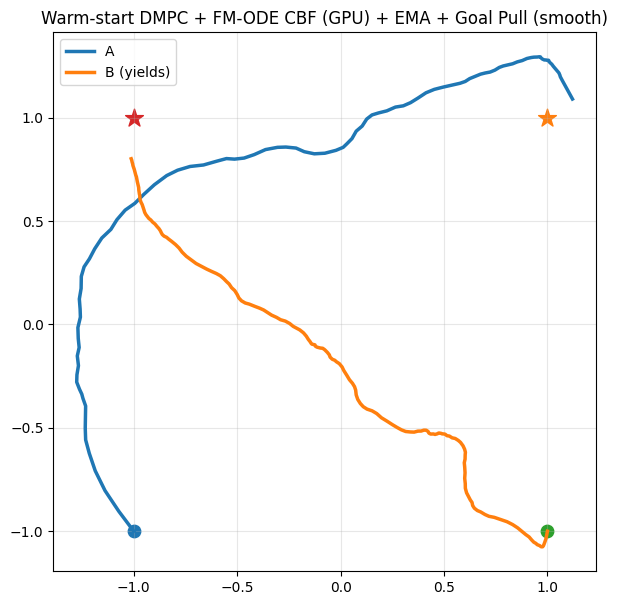

In [ ]:


# ---------------------------------------------------------------
# Geometry helpers (TORCH)
# ---------------------------------------------------------------
#自动猜模型想要的 cond 维度
def infer_cond_dim(model):
    if hasattr(model, "cond_dim") and model.cond_dim is not None:
        return int(model.cond_dim)
    if hasattr(model, "cond_mlp"):
        for l in model.cond_mlp:
            if hasattr(l, "in_features"):
                return int(l.in_features)
    return None

#把“世界坐标”转到“canonical 坐标”
def rot2_t(a: torch.Tensor):
    # a: scalar tensor
    c, s = torch.cos(a), torch.sin(a)
    return torch.stack([torch.stack([c, -s]),
                        torch.stack([s,  c])], dim=0)  # (2,2)

#几何关系转成cond
@torch.no_grad()
def canonicalize_t(x: torch.Tensor, g: torch.Tensor, obs: torch.Tensor):
    """
    x,g,obs: (2,) torch
    return:
      cond3: (3,) torch float32
      meta: dict(phi: scalar tensor, reflect: python bool)
    """
    g0 = g - x   #从当前位置指向目标向量
    o0 = obs - x   #
    dist = torch.linalg.norm(g0) + 1e-9
    phi = torch.atan2(g0[1], g0[0])
    R = rot2_t(-phi)  #旋转 让goal对齐到+x
    o_can = R @ o0  # (2,) #把障碍物旋转到canonical坐标

    reflect = bool((o_can[1] < 0).item())
    if reflect:
        o_can = o_can.clone()
        o_can[1] = -o_can[1]

    cond3 = torch.stack([dist, o_can[0], o_can[1]]).to(dtype=torch.float32)
    meta = dict(phi=phi, reflect=reflect)
    return cond3, meta

#先镜像回来
@torch.no_grad()
def uncanonicalize_t(v_can: torch.Tensor, meta: dict):
    """
    v_can: (2,) torch
    meta: {phi: scalar tensor, reflect: bool}
    """
    v = v_can #把canonical速度变回世界速度
    if meta["reflect"]:
        v = v.clone()
        v[1] = -v[1]
    return rot2_t(meta["phi"]) @ v

# ---------------------------------------------------------------
# FM ODE sampler (CBF inside, first-step only) — GPU-friendly
# ---------------------------------------------------------------
@torch.no_grad()
def sample_fm_traj_with_cbf(
    x_self, g_self, other_traj,
    *, H, dt, v_max, speed_scale,
    r_stop=1.0, noise_scale=1.0, ode_steps=30,
    other_radius=0.6, cbf_passes=3,
):

    #把输入一次性转成 torch
    # ---- convert ONCE to torch on device ----
    x_self_t = torch.tensor(x_self, device=device, dtype=torch.float32)  # (2,) 
    g_self_t  = torch.tensor(g_self,  device=device, dtype=torch.float32)  # (2,)

    other_traj_t = torch.tensor(other_traj, device=device, dtype=torch.float32)  # (H+1,2) typically
    other_center_t = other_traj_t[1]  # (2,)拿对方轨迹的下一步作为对方中心

    # ---- canonicalize (torch) ----
    cond3_t, meta = canonicalize_t(x_self_t, g_self_t, other_traj_t[0]) #对方当前位置（用于 cond）

    #初始化 ODE 起点
    # ---- pad/truncate cond to model's expected cond_dim ----自动形成cond-t
    cond_dim = infer_cond_dim(model_vel)
    if cond_dim is None:
        cond_t = cond3_t.view(1, -1)
    else:
        if cond3_t.numel() < cond_dim:
            pad = torch.zeros(cond_dim - cond3_t.numel(), device=device, dtype=cond3_t.dtype)
            cond_full = torch.cat([cond3_t, pad], dim=0)
        else:
            cond_full = cond3_t[:cond_dim]
        cond_t = cond_full.view(1, -1)

    # ---- init ----
    x0 = torch.randn(1, 2, H, device=device) * noise_scale
    t_span = torch.linspace(0.0, 1.0, ode_steps + 1, device=device)

    # Pre-build tensors used in CBF call (no re-creation in rhs)
    x_self_cbf = x_self_t.view(1, 2, 1)  # (1,2,1)

    # NOTE:
    # If your CBF implementation does NOT accept torch tensor centers,
    # uncomment the next line and change ellipses center below to other_center_np.
    # other_center_np = other_center_t.detach().cpu().numpy()

    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 2, H)
        t_t = torch.tensor([t], device=device, dtype=x.dtype)

        # model outputs canonical velocity field
        v_can = model_vel(x, t_t, cond=cond_t)  # (1,2,H)FM 在 canonical frame 输出整段速度场

        # ---- CBF only on first step (k=0) ----
        v0_can = v_can[0, :, 0]                      # (2,) 是第一个时间步
        v0_world = uncanonicalize_t(v0_can, meta)    # (2,) 速度变回世界坐标速度
        v0_world_cbf = v0_world.view(1, 2, 1)        # (1,2,1) 

        v0_safe = cbf_project_velocity_world(
            x_self_cbf,
            v0_world_cbf,
            ellipses=[{"center": other_center_t, "radius": float(other_radius)}],
            passes=int(cbf_passes),
        )[0, :, 0]  # (2,)

        # If your cbf expects numpy:
        # v0_safe = cbf_project_velocity_world(
        #     x_self_cbf, v0_world_cbf,
        #     ellipses=[{"center": other_center_np, "radius": float(other_radius)}],
        #     passes=int(cbf_passes),
        # )[0, :, 0]

        # back to canonical
        v0_safe_can = rot2_t(-meta["phi"]) @ v0_safe
        if meta["reflect"]:
            v0_safe_can = v0_safe_can.clone()
            v0_safe_can[1] = -v0_safe_can[1]

        v_can = v_can.clone()
        v_can[0, :, 0] = v0_safe_can

        return v_can.reshape(-1)

    sol = torchdiffeq.odeint(
        fm_ode_func,
        x0.reshape(-1),
        t_span,
        method="euler",
    )

    # final canonical velocity sequence (H,2) on CPU numpy for rollout loop
    v_can_seq = sol[-1].view(2, H).transpose(0, 1).detach().cpu().numpy()

    # ---- rollout (cheap; keep numpy like before) ----
    v_seq = np.zeros((H, 2))
    traj = [np.asarray(x_self, dtype=float).copy()]
    xk = traj[0].copy()
    g_np = np.asarray(g_self, dtype=float)

    for k in range(H):
        d_goal = np.linalg.norm(xk - g_np)
        speed = v_max * speed_scale * min(1.0, d_goal / r_stop)

        v_can_k = torch.tensor(v_can_seq[k], device=device, dtype=torch.float32)
        v_w_t = uncanonicalize_t(v_can_k, meta)
        v_w = v_w_t.detach().cpu().numpy()

        v_w = speed * v_w / (np.linalg.norm(v_w) + 1e-9)
        v_seq[k] = v_w
        xk = xk + dt * v_w
        traj.append(xk.copy())

    return v_seq, np.asarray(traj)

# ---------------------------------------------------------------
# Smoothing utilities
# ---------------------------------------------------------------
def ema(v_new, v_prev, beta):
    if v_prev is None:
        return v_new
    return beta * v_prev + (1 - beta) * v_new

def goal_pull(v, x, g, alpha=0.25):
    d = g - x
    d = d / (np.linalg.norm(d) + 1e-9)
    v_dir = v / (np.linalg.norm(v) + 1e-9)
    if np.dot(v_dir, d) < 0.0:
        v = (1 - alpha) * v + alpha * np.linalg.norm(v) * d
    return v

# ---------------------------------------------------------------
# Warm-start DMPC loop
# ---------------------------------------------------------------
def two_car_warmstart_dmpc(
    xA0, gA, xB0, gB,
    *, dt=0.1, H=15,
    vA_max=1.4, vB_max=1.4,
    speed_A=1.0, speed_B=0.4,
    r_stop=1.0, goal_tol=0.2,
    max_steps=600,
    ema_beta=0.9,
    ode_steps=30,
):
    xA = np.array(xA0, dtype=float)
    xB = np.array(xB0, dtype=float)
    gA = np.array(gA, dtype=float)
    gB = np.array(gB, dtype=float)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    def straight_pred(x, g, v_max, s):
        d = g - x
        d = d / (np.linalg.norm(d) + 1e-9)
        traj = [x.copy()]
        for _ in range(H):
            x = x + dt * v_max * s * d
            traj.append(x.copy())
        return np.asarray(traj)

    predA = straight_pred(xA, gA, vA_max, speed_A)
    predB = straight_pred(xB, gB, vB_max, speed_B)

    for step in range(max_steps):
        if np.linalg.norm(xA - gA) < goal_tol:
            predA = np.tile(gA, (H + 1, 1))
        if np.linalg.norm(xB - gB) < goal_tol:
            predB = np.tile(gB, (H + 1, 1))

        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        if np.linalg.norm(xA - gA) >= goal_tol:
            vA_seq, predA = sample_fm_traj_with_cbf(
                xA, gA, predB_shift,
                H=H, dt=dt,
                v_max=vA_max, speed_scale=speed_A,
                r_stop=r_stop,
                ode_steps=ode_steps,
            )
            vA0 = vA_seq[0]
        else:
            vA0 = np.zeros(2)

        if np.linalg.norm(xB - gB) >= goal_tol:
            vB_seq, predB = sample_fm_traj_with_cbf(
                xB, gB, predA_shift,
                H=H, dt=dt,
                v_max=vB_max, speed_scale=speed_B,
                r_stop=r_stop,
                ode_steps=ode_steps,
            )
            vB0 = vB_seq[0]
        else:
            vB0 = np.zeros(2)

        # ---- EMA + goal pull ----
        vA_exec = ema(vA0, prev_vA, ema_beta)
        vB_exec = ema(vB0, prev_vB, ema_beta)

        alpha_A = 0.15
        alpha_B = 0.20  # B yields => a bit stronger pull

        vA_exec = goal_pull(vA_exec, xA, gA, alpha=alpha_A)
        vB_exec = goal_pull(vB_exec, xB, gB, alpha=alpha_B)

        xA = xA + dt * vA_exec
        xB = xB + dt * vB_exec

        xsA.append(xA.copy())
        xsB.append(xB.copy())
        prev_vA, prev_vB = vA_exec.copy(), vB_exec.copy()

        if np.linalg.norm(xA - gA) < goal_tol and np.linalg.norm(xB - gB) < goal_tol:
            break

    return np.asarray(xsA), np.asarray(xsB)

# ---------------------------------------------------------------
# Demo
# ---------------------------------------------------------------
xA0 = [-1.0, -1.0]; gA = [1.0, 1.0]
xB0 = [ 1.0, -1.0]; gB = [-1.0, 1.0]

xsA, xsB = two_car_warmstart_dmpc(
    xA0, gA, xB0, gB,
    dt=0.1, H=15,
    ode_steps=30,   # try 10-12 first if still slow
)

plt.figure(figsize=(7, 7))
plt.plot(xsA[:, 0], xsA[:, 1], lw=2.5, label="A")
plt.plot(xsB[:, 0], xsB[:, 1], lw=2.5, label="B (yields)")
plt.scatter([xA0[0]], [xA0[1]], s=80)
plt.scatter([gA[0]],  [gA[1]],  marker="*", s=180)
plt.scatter([xB0[0]], [xB0[1]], s=80)
plt.scatter([gB[0]],  [gB[1]],  marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend()
plt.title("Warm-start DMPC + FM-ODE CBF (GPU) + EMA + Goal Pull (smooth)")
plt.show()


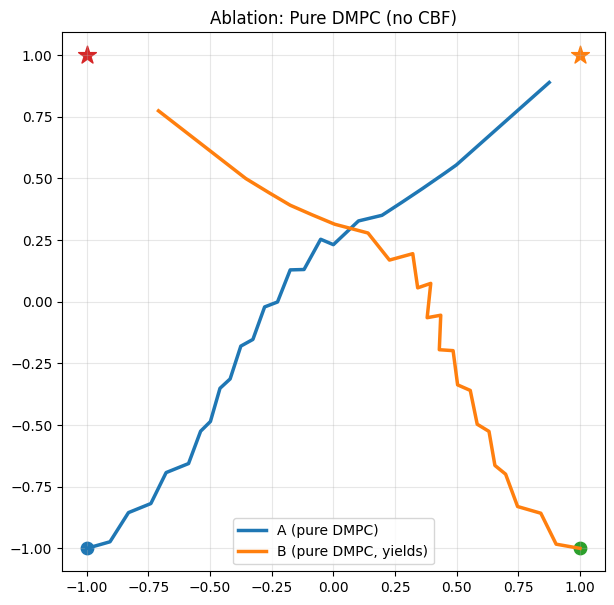

In [ ]:
# ===============================================================
# ABLATION CELL 1: Pure DMPC (dynamics + cost), NO CBF
# - Two agents, point-mass kinematics x_{t+1} = x_t + dt * v
# - DMPC warm-start: each agent plans against the OTHER's last predicted trajectory
# - Candidate actions: heading grid around goal direction + discrete speed scales
# - Cost: goal + smooth(turn) + soft distance violation + speed preference (optional)
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt

def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)

def _unit(v):
    n = float(np.linalg.norm(v) + 1e-9)
    return v / n

def straight_pred(x, g, dt, v_max, s, H):
    d = _unit(g - x)
    traj = [x.copy()]
    xk = x.copy()
    for _ in range(int(H)):
        xk = xk + float(dt) * float(v_max) * float(s) * d
        traj.append(xk.copy())
    return np.asarray(traj, dtype=np.float64)

def rollout_from_action(x0, v_seq, dt):
    x = x0.copy()
    traj = [x.copy()]
    for k in range(v_seq.shape[0]):
        x = x + float(dt) * v_seq[k]
        traj.append(x.copy())
    return np.asarray(traj, dtype=np.float64)

def dmcp_pick_best_action(
    x, g, other_pred,
    *,
    dt, H,
    v_max,
    speed_scales,
    heading_span_deg=140.0,
    heading_samples=25,
    d_safe=1.05,
    # costs
    w_goal=35.0,
    w_dist=100.0,
    w_turn=1.5,
    w_speed=0.2,
    prev_v=None,
):
    # base heading = goal direction
    d_goal = g - x
    base = float(np.arctan2(d_goal[1], d_goal[0]))
    span = np.deg2rad(float(heading_span_deg))
    offs = np.linspace(-span/2.0, span/2.0, int(heading_samples), dtype=np.float64)

    bestJ = float("inf")
    best_v0 = np.zeros(2, dtype=np.float64)
    best_traj = None

    def hinge(z): return max(0.0, float(z))

    for off in offs:
        h = float(base + off)
        dirv = np.array([np.cos(h), np.sin(h)], dtype=np.float64)

        for s in speed_scales:
            s = float(s)
            v0 = float(v_max) * s * dirv

            # build a constant-v sequence for horizon (simple dynamics)
            v_seq = np.repeat(v0[None, :], int(H), axis=0)

            # evaluate cost
            xk = x.copy()
            J = 0.0
            v_prev = prev_v

            for k in range(int(H)):
                xk1 = xk + float(dt) * v_seq[k]

                # distance-to-other uses other_pred[k+1]
                d = float(np.linalg.norm(xk1 - other_pred[k + 1]))
                viol = hinge(float(d_safe) - d)
                J += float(w_dist) * (viol * viol)

                # turn/smooth: penalize deviation from prev_v at first step
                if v_prev is not None and k == 0:
                    dv0 = v_seq[0] - v_prev
                    J += float(w_turn) * float(dv0 @ dv0)

                xk = xk1

            # terminal goal
            J += float(w_goal) * float(np.sum((xk - g) ** 2))
            # speed preference (discourage too slow)
            J += float(w_speed) * float((1.0 - s) ** 2)

            if J < bestJ:
                bestJ = J
                best_v0 = v0.copy()
                best_traj = rollout_from_action(x, v_seq, dt)

    return best_v0, best_traj


def two_car_pure_dmpc(
    xA0, gA, xB0, gB,
    *,
    dt=0.1,
    H=15,
    vA_max=1.4,
    vB_max=1.4,
    max_steps=600,
    goal_tol=0.20,
    # candidate sets
    speed_scales_A=(0.4, 0.7, 1.0),
    speed_scales_B=(0.0, 0.4, 0.7, 1.0),  # B can yield (stop)
    heading_span_deg=140.0,
    heading_samples=25,
    # safety in cost
    d_safe=1.05,
    # costs (asym yield)
    w_goal_A=35.0, w_goal_B=35.0,
    w_dist_A=80.0, w_dist_B=120.0,   # B yields more
    w_turn_A=1.5,  w_turn_B=1.5,
    w_speed_A=0.2, w_speed_B=0.4,
    # best response iters
    n_best_response_iters=1,
):
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    # warm-start initial guesses: straight to goal
    predA = straight_pred(xA, gA, dt, vA_max, speed_scales_A[-1], H)
    predB = straight_pred(xB, gB, dt, vB_max, speed_scales_B[-1], H)

    for step in range(int(max_steps)):
        doneA = float(np.linalg.norm(xA - gA)) < float(goal_tol)
        doneB = float(np.linalg.norm(xB - gB)) < float(goal_tol)
        if doneA and doneB:
            break

        # shift opponent predictions (warm-start DMPC)
        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        vA0 = np.zeros(2, dtype=np.float64)
        vB0 = np.zeros(2, dtype=np.float64)

        # best-response loop (optional)
        for _ in range(int(max(1, n_best_response_iters))):
            if not doneA:
                vA0, predA = dmcp_pick_best_action(
                    xA, gA, predB_shift,
                    dt=dt, H=H, v_max=vA_max,
                    speed_scales=speed_scales_A,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_A, w_dist=w_dist_A, w_turn=w_turn_A, w_speed=w_speed_A,
                    prev_v=prev_vA,
                )

            if not doneB:
                vB0, predB = dmcp_pick_best_action(
                    xB, gB, predA_shift,
                    dt=dt, H=H, v_max=vB_max,
                    speed_scales=speed_scales_B,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_B, w_dist=w_dist_B, w_turn=w_turn_B, w_speed=w_speed_B,
                    prev_v=prev_vB,
                )

        if doneA: vA0[:] = 0.0
        if doneB: vB0[:] = 0.0

        # execute one step (no CBF)
        xA = xA + float(dt) * vA0
        xB = xB + float(dt) * vB0
        xsA.append(xA.copy()); xsB.append(xB.copy())
        prev_vA, prev_vB = vA0.copy(), vB0.copy()

    return np.asarray(xsA), np.asarray(xsB)


# -------------------------
# Run + Plot (same scenario)
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

xsA_pure, xsB_pure = two_car_pure_dmpc(
    xA0, gA, xB0, gB,
    dt=0.1,
    H=15,
    vA_max=1.4, vB_max=1.4,
    goal_tol=0.20,
    n_best_response_iters=1,
)

plt.figure(figsize=(7,7))
plt.plot(xsA_pure[:,0], xsA_pure[:,1], lw=2.5, label="A (pure DMPC)")
plt.plot(xsB_pure[:,0], xsB_pure[:,1], lw=2.5, label="B (pure DMPC, yields)")
plt.scatter([xA0[0]],[xA0[1]], s=80)
plt.scatter([gA[0]],[gA[1]], marker="*", s=180)
plt.scatter([xB0[0]],[xB0[1]], s=80)
plt.scatter([gB[0]],[gB[1]], marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend()
plt.title("Ablation: Pure DMPC (no CBF)")
plt.show()


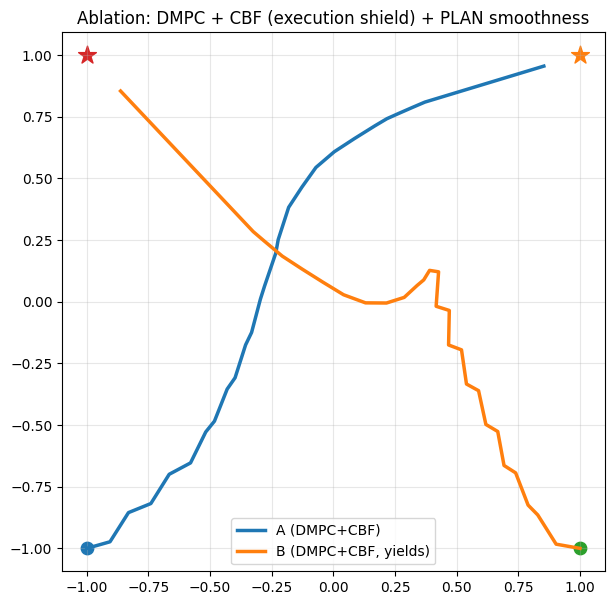

In [48]:
# ===============================================================
# ABLATION CELL 2 (FIXED): DMPC + CBF (execution shield)
# + PLAN-LEVEL SMOOTHNESS (no post-CBF EMA/turn-limit)
#
# Key idea:
#   - Add strong smoothness in the DMPC pick-best step:
#       (1) angle change penalty between v0 and prev_v
#       (2) dv penalty between v0 and prev_v
#   - Execution: ONLY CBF projection (no extra filtering after CBF)
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found. Run your CBF cell first.")

# ---------- utils ----------
def wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2*np.pi) - np.pi)

def straight_pred(x, g, dt, v_max, s, H):
    x = np.asarray(x, dtype=np.float64).reshape(2).copy()
    g = np.asarray(g, dtype=np.float64).reshape(2).copy()
    d = g - x
    d = d / (np.linalg.norm(d) + 1e-9)
    traj = [x.copy()]
    for _ in range(int(H)):
        x = x + float(dt) * float(v_max) * float(s) * d
        traj.append(x.copy())
    return np.asarray(traj, dtype=np.float64)

def cbf_step_other_center(
    x_now, v_nom, other_now,
    *,
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    extra_margin=0.0,
):
    x_now = np.asarray(x_now, dtype=np.float64).reshape(2)
    v_nom = np.asarray(v_nom, dtype=np.float64).reshape(2)
    other_now = np.asarray(other_now, dtype=np.float64).reshape(2)

    ellipses = [{"center": other_now.copy(), "radius": float(agent_safe_radius)}]
    x_traj = torch.tensor(x_now, dtype=torch.float32).view(1, 2, 1)
    v_traj = torch.tensor(v_nom, dtype=torch.float32).view(1, 2, 1)

    v_safe = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses=ellipses,
        extra_margin=float(extra_margin),
        max_corr_norm=float(max_corr_norm),
        passes=3,
        other_agents_traj=None,
        agent_safe_radius=float(agent_safe_radius),
        gamma_min=float(gamma_min),
        w_p=float(w_p),
        press_k=float(press_k),
        press_n=float(press_n),
    )
    return v_safe[0, :, 0].detach().cpu().numpy().astype(np.float64)

def _hinge(z): 
    return max(0.0, float(z))

def _angle_between(u, v):
    nu = float(np.linalg.norm(u) + 1e-12)
    nv = float(np.linalg.norm(v) + 1e-12)
    uu = u / nu
    vv = v / nv
    c = float(np.clip(np.dot(uu, vv), -1.0, 1.0))
    return float(np.arccos(c))  # [0,pi]

def rollout_pred(x0, v0, dt, H):
    x = np.asarray(x0, dtype=np.float64).reshape(2).copy()
    traj = [x.copy()]
    for _ in range(int(H)):
        x = x + float(dt) * v0
        traj.append(x.copy())
    return np.asarray(traj, dtype=np.float64)

# ---------- smooth DMPC pick-best (single-step action candidates) ----------
def dmcp_pick_best_action_smooth(
    xSelf, gSelf, other_pred,
    *,
    dt, H, v_max,
    speed_scales,
    heading_span_deg=140.0,
    heading_samples=25,
    d_safe=1.05,
    w_goal=35.0,
    w_dist=100.0,
    w_speed=0.3,
    # NEW smoothness
    prev_v=None,
    w_dv=6.0,          # dv penalty (stronger => less jitter)
    w_dtheta=12.0,     # angle change penalty (very effective)
):
    xSelf = np.asarray(xSelf, dtype=np.float64).reshape(2)
    gSelf = np.asarray(gSelf, dtype=np.float64).reshape(2)
    other_pred = np.asarray(other_pred, dtype=np.float64)

    base = float(np.arctan2((gSelf-xSelf)[1], (gSelf-xSelf)[0]))
    span = np.deg2rad(float(heading_span_deg))
    offs = np.linspace(-span/2.0, span/2.0, int(heading_samples))

    bestJ = 1e18
    bestv0 = np.zeros(2, dtype=np.float64)

    for off in offs:
        th = float(base + off)
        dir_vec = np.array([np.cos(th), np.sin(th)], dtype=np.float64)
        for s in speed_scales:
            v0 = float(v_max) * float(s) * dir_vec

            # rollout with constant v0
            x = xSelf.copy()
            J = 0.0
            for k in range(int(H)):
                x = x + float(dt) * v0

                d = float(np.linalg.norm(x - other_pred[k+1]))
                viol = _hinge(float(d_safe) - d)
                J += float(w_dist) * (viol*viol)

            # terminal goal cost
            J += float(w_goal) * float(np.sum((x - gSelf)**2))

            # speed choice penalty
            J += float(w_speed) * float((1.0 - float(s))**2)

            # smoothness vs prev_v
            if prev_v is not None:
                dv = v0 - prev_v
                J += float(w_dv) * float(dv @ dv)
                J += float(w_dtheta) * (_angle_between(v0, prev_v)**2)

            if J < bestJ:
                bestJ = J
                bestv0 = v0.copy()

    pred_self = rollout_pred(xSelf, bestv0, dt, H)  # for the other agent
    return bestv0, pred_self

# ---------- main loop ----------
def two_car_dmpc_with_cbf(
    xA0, gA, xB0, gB,
    *,
    dt=0.1,
    H=15,
    vA_max=1.4,
    vB_max=1.4,
    max_steps=600,
    goal_tol=0.20,
    speed_scales_A=(0.4, 0.7, 1.0),
    speed_scales_B=(0.0, 0.4, 0.7, 1.0),
    heading_span_deg=140.0,
    heading_samples=25,
    d_safe=1.05,
    w_goal_A=35.0, w_goal_B=35.0,
    w_dist_A=80.0, w_dist_B=120.0,
    w_speed_A=0.2, w_speed_B=0.4,
    n_best_response_iters=1,
    # NEW smoothness
    w_dv_A=6.0, w_dtheta_A=12.0,
    w_dv_B=6.0, w_dtheta_B=12.0,
    # CBF params
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
):
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    predA = straight_pred(xA, gA, dt, vA_max, speed_scales_A[-1], H)
    predB = straight_pred(xB, gB, dt, vB_max, speed_scales_B[-1], H)

    for step in range(int(max_steps)):
        doneA = float(np.linalg.norm(xA - gA)) < float(goal_tol)
        doneB = float(np.linalg.norm(xB - gB)) < float(goal_tol)
        if doneA and doneB:
            break

        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        vA0 = np.zeros(2, dtype=np.float64)
        vB0 = np.zeros(2, dtype=np.float64)

        for _ in range(int(max(1, n_best_response_iters))):
            if not doneA:
                vA0, predA = dmcp_pick_best_action_smooth(
                    xA, gA, predB_shift,
                    dt=dt, H=H, v_max=vA_max,
                    speed_scales=speed_scales_A,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_A, w_dist=w_dist_A, w_speed=w_speed_A,
                    prev_v=prev_vA,
                    w_dv=w_dv_A, w_dtheta=w_dtheta_A,
                )
            if not doneB:
                vB0, predB = dmcp_pick_best_action_smooth(
                    xB, gB, predA_shift,
                    dt=dt, H=H, v_max=vB_max,
                    speed_scales=speed_scales_B,
                    heading_span_deg=heading_span_deg,
                    heading_samples=heading_samples,
                    d_safe=d_safe,
                    w_goal=w_goal_B, w_dist=w_dist_B, w_speed=w_speed_B,
                    prev_v=prev_vB,
                    w_dv=w_dv_B, w_dtheta=w_dtheta_B,
                )

        if doneA: vA0[:] = 0.0
        if doneB: vB0[:] = 0.0

        # ---- execute ONLY through CBF (no post-filter) ----
        vA_exec = cbf_step_other_center(
            xA, vA0, xB,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p,
            press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
        )
        vB_exec = cbf_step_other_center(
            xB, vB0, xA,
            agent_safe_radius=agent_safe_radius,
            gamma_min=gamma_min, w_p=w_p,
            press_k=press_k, press_n=press_n,
            max_corr_norm=max_corr_norm,
        )

        xA = xA + float(dt) * vA_exec
        xB = xB + float(dt) * vB_exec
        xsA.append(xA.copy()); xsB.append(xB.copy())

        prev_vA, prev_vB = vA0.copy(), vB0.copy()

    return np.asarray(xsA), np.asarray(xsB)

# -------------------------
# Run + Plot (same scenario)
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

xsA_cbf, xsB_cbf = two_car_dmpc_with_cbf(
    xA0, gA, xB0, gB,
    dt=0.1,
    H=15,
    vA_max=1.4, vB_max=1.4,
    goal_tol=0.20,
    n_best_response_iters=1,
    agent_safe_radius=0.60,
    # ⭐如果还尖，继续加大：
    # w_dtheta_A=20, w_dtheta_B=20,
    # w_dv_A=10, w_dv_B=10,
)

plt.figure(figsize=(7,7))
plt.plot(xsA_cbf[:,0], xsA_cbf[:,1], lw=2.5, label="A (DMPC+CBF)")
plt.plot(xsB_cbf[:,0], xsB_cbf[:,1], lw=2.5, label="B (DMPC+CBF, yields)")
plt.scatter([xA0[0]],[xA0[1]], s=80)
plt.scatter([gA[0]],[gA[1]], marker="*", s=180)
plt.scatter([xB0[0]],[xB0[1]], s=80)
plt.scatter([gB[0]],[gB[1]], marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend()
plt.title("Ablation: DMPC + CBF (execution shield) + PLAN smoothness")
plt.show()


In [75]:
# ===============================================================
# CELL: "Easy-to-run" Ablation Eval (Group1 uses NEW GPU-friendly warmstart)
# Compare:
#   - collision_rate
#   - min_dist_avg / min_dist_global
#   - avg_tracking_error (to straight line)
#   - avg_time_sec
# Also logs fail_rate (if a controller errors)
#
# Assumption:
#   - two_car_warmstart_dmpc is your NEW gpu-friendly lightweight version
#     (with replan_every, ode_steps)
#   - Group2/3 funcs unchanged: two_car_pure_dmpc, two_car_dmpc_with_cbf
# ===============================================================

import numpy as np
import time
import inspect

# -----------------------------
# 0) Preconditions
# -----------------------------
need = ["two_car_warmstart_dmpc", "two_car_pure_dmpc", "two_car_dmpc_with_cbf"]
for n in need:
    if n not in globals():
        raise RuntimeError(f"{n} not found. Please run the cell that defines it first.")

# -----------------------------
# 1) Safe call: only pass args that the function accepts
# -----------------------------
def _call_with_accepted_kwargs(func, *args, **kwargs):
    sig = inspect.signature(func)
    accepted = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return func(*args, **accepted)

# -----------------------------
# 2) Metrics helpers
# -----------------------------
def _min_dist_series(xsA, xsB):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)
    d = np.linalg.norm(xsA - xsB, axis=1)
    return float(d.min()), float(d.mean())

def _point_to_segment_dist(p, a, b):
    p = np.asarray(p, float); a = np.asarray(a, float); b = np.asarray(b, float)
    ab = b - a
    t = float(np.dot(p - a, ab) / (np.dot(ab, ab) + 1e-12))
    t = max(0.0, min(1.0, t))
    proj = a + t * ab
    return float(np.linalg.norm(p - proj))

def _tracking_error_to_line(xs, start, goal):
    start = np.asarray(start, float); goal = np.asarray(goal, float)
    errs = [_point_to_segment_dist(p, start, goal) for p in np.asarray(xs, float)]
    return float(np.mean(errs))

def _episode_metrics(xsA, xsB, xA0, gA, xB0, gB, *, collision_dist):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)
    min_d, mean_d = _min_dist_series(xsA, xsB)
    collided = (min_d < float(collision_dist))

    errA = _tracking_error_to_line(xsA, xA0, gA)
    errB = _tracking_error_to_line(xsB, xB0, gB)
    avg_track_err = 0.5 * (errA + errB)

    return dict(
        collided=bool(collided),
        min_dist=min_d,
        mean_dist=mean_d,
        avg_track_err=avg_track_err,
        steps=int(len(xsA) - 1),
    )

# -----------------------------
# 3) Scenario generator
# -----------------------------
def make_crossing_scenarios(M=10, seed=0):
    rng = np.random.default_rng(seed)
    base = {
        "xA0": np.array([-1.0, -1.0]),
        "gA":  np.array([+1.0, +1.0]),
        "xB0": np.array([+1.0, -1.0]),
        "gB":  np.array([-1.0, +1.0]),
    }
    scenarios = []
    for _ in range(M):
        ang = rng.uniform(-np.pi, np.pi)
        s = rng.uniform(0.9, 1.25)
        R = np.array([[np.cos(ang), -np.sin(ang)],
                      [np.sin(ang),  np.cos(ang)]], float)
        sc = {}
        for k, v in base.items():
            sc[k] = (s * (R @ v.reshape(2, 1)).reshape(2)).astype(float)
        scenarios.append(sc)
    return scenarios

# -----------------------------
# 4) Runners
#   - Group1: NEW gpu-friendly warmstart DMPC (replan + ode_steps)
#   - Group2/3: unchanged (defaults)
# -----------------------------
def run_group1(sc, cfg):
    # IMPORTANT: this calls your NEW "gpu-friendly lightweight" two_car_warmstart_dmpc
    return _call_with_accepted_kwargs(
        two_car_warmstart_dmpc,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        speed_A=cfg["speed_A"], speed_B=cfg["speed_B"],
        r_stop=cfg["r_stop"], goal_tol=cfg["goal_tol"],
        max_steps=cfg["max_steps"],
        ema_beta=cfg["ema_beta"],
        replan_every=cfg["replan_every"],
        ode_steps=cfg["ode_steps"],
        # If your new implementation supports these, it will take them;
        # otherwise they are auto-filtered by _call_with_accepted_kwargs.
        # (leave here so you can extend later without touching this cell)
    )

def run_group2(sc, cfg):
    # Pure DMPC (DO NOT pass weights now)
    return _call_with_accepted_kwargs(
        two_car_pure_dmpc,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
    )

def run_group3(sc, cfg):
    # DMPC + exec CBF shield (DO NOT pass weights now)
    return _call_with_accepted_kwargs(
        two_car_dmpc_with_cbf,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
        # If it accepts CBF params, it'll use them; otherwise filtered out.
        agent_safe_radius=cfg["agent_safe_radius"],
        gamma_min=cfg["gamma_min"],
        w_p=cfg["w_p"],
        press_k=cfg["press_k"],
        press_n=cfg["press_n"],
        max_corr_norm=cfg["max_corr_norm"],
    )

controllers = {
    "Group1: NEW Warmstart FM (GPU-friendly, replan)": run_group1,
    "Group2: Pure-DMPC (defaults)": run_group2,
    "Group3: DMPC+CBF exec (defaults)": run_group3,
}

# -----------------------------
# 5) Config: reportable
# -----------------------------
cfg = dict(
    dt=0.1,
    H=10,
    max_steps=250,
    goal_tol=0.20,
    vA_max=1.4,
    vB_max=1.4,

    # Group1 specific (tune here)
    speed_A=1.0,
    speed_B=0.4,
    r_stop=1.0,
    ema_beta=0.90,
    replan_every=5,
    ode_steps=10,   # try 6~12 on GPU, 8~15 on CPU

    # CBF gains (Group3; also used for collision metric threshold)
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
)

collision_dist = cfg["agent_safe_radius"]

# -----------------------------
# 6) Run eval with progress + fail tolerance
# -----------------------------
scenarios = make_crossing_scenarios(M=10, seed=0)

print("=== Eval Config (easy version) ===")
print(f"M={len(scenarios)}, dt={cfg['dt']}, H={cfg['H']}, max_steps={cfg['max_steps']}")
print(f"Group1 (NEW) replan_every={cfg['replan_every']}, ode_steps={cfg['ode_steps']}")
print("Weights are NOT passed for Group2/3 (use their internal defaults).")
print("")

results = {}
for name, runner in controllers.items():
    ep_stats, t_list = [], []
    fail = 0

    print(f"Running [{name}]")
    for i, sc in enumerate(scenarios):
        t0 = time.perf_counter()
        try:
            xsA, xsB = runner(sc, cfg)
            t_list.append(time.perf_counter() - t0)
            ep_stats.append(_episode_metrics(
                xsA, xsB,
                sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
                collision_dist=collision_dist
            ))
        except Exception as e:
            fail += 1
            t_list.append(time.perf_counter() - t0)

        if (i + 1) % 2 == 0:
            print(f"  {i+1}/{len(scenarios)} done | avg_time={np.mean(t_list):.2f}s | fails={fail}")

    ok = len(ep_stats)
    if ok == 0:
        results[name] = dict(
            fail_rate=1.0,
            note="All episodes failed (check controller)."
        )
        continue

    collision_rate  = float(np.mean([s["collided"] for s in ep_stats]))
    min_dist_avg    = float(np.mean([s["min_dist"] for s in ep_stats]))
    min_dist_global = float(np.min([s["min_dist"] for s in ep_stats]))
    track_err_avg   = float(np.mean([s["avg_track_err"] for s in ep_stats]))
    time_avg        = float(np.mean(t_list))

    results[name] = dict(
        fail_rate=float(fail / len(scenarios)),
        collision_rate=collision_rate,
        min_dist_avg=min_dist_avg,
        min_dist_global=min_dist_global,
        avg_tracking_error=track_err_avg,
        avg_time_sec=time_avg,
        steps_avg=float(np.mean([s["steps"] for s in ep_stats])),
        episodes_ok=ok,
    )

print("\n=== EASY ABLATION RESULTS ===")
for k, v in results.items():
    print(f"\n[{k}]")
    for kk, vv in v.items():
        if isinstance(vv, float):
            print(f"  {kk:>18s}: {vv:.4f}")
        else:
            print(f"  {kk:>18s}: {vv}")


=== Eval Config (easy version) ===
M=10, dt=0.1, H=10, max_steps=250
Group1 (NEW) replan_every=5, ode_steps=10
Weights are NOT passed for Group2/3 (use their internal defaults).

Running [Group1: NEW Warmstart FM (GPU-friendly, replan)]
  2/10 done | avg_time=21.06s | fails=0
  4/10 done | avg_time=27.90s | fails=0
  6/10 done | avg_time=24.13s | fails=0
  8/10 done | avg_time=77.29s | fails=0
  10/10 done | avg_time=65.87s | fails=0
Running [Group2: Pure-DMPC (defaults)]
  2/10 done | avg_time=0.91s | fails=0
  4/10 done | avg_time=0.95s | fails=0
  6/10 done | avg_time=0.94s | fails=0
  8/10 done | avg_time=0.93s | fails=0
  10/10 done | avg_time=0.93s | fails=0
Running [Group3: DMPC+CBF exec (defaults)]
  2/10 done | avg_time=0.27s | fails=0
  4/10 done | avg_time=0.28s | fails=0
  6/10 done | avg_time=0.29s | fails=0
  8/10 done | avg_time=0.28s | fails=0
  10/10 done | avg_time=0.27s | fails=0

=== EASY ABLATION RESULTS ===

[Group1: NEW Warmstart FM (GPU-friendly, replan)]
      

In [26]:
# ===============================================================
# VERIFY CELL — confirm your import chain is clean (module vs function)
# For 2carexperiment.ipynb
# - prints: repo root, sys.path status
# - imports sampler + cbf as MODULES
# - verifies: __file__, callable, and sampler's resolver target
# ===============================================================

import sys
from pathlib import Path
import importlib
import types

# -----------------------
# 0) locate repo root (the folder that contains "dmpc_fm_cbf/")
# -----------------------
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(15):
        if (p / "dmpc_fm_cbf").exists():
            return p
        p = p.parent
    return start.resolve()

CWD = Path.cwd().resolve()
REPO_ROOT = find_repo_root(CWD)
print("[CWD      ]", CWD)
print("[REPO_ROOT ]", REPO_ROOT)

# ensure REPO_ROOT in sys.path so `import dmpc_fm_cbf...` works
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("[sys.path0]", sys.path[0])

# -----------------------
# 1) hard clean possible name collisions in notebook namespace
#    (common mistake: cbfmod = cbf_project_velocity_sgfm function)
# -----------------------
for name in ["cbfmod", "cbf_mod", "sampler_5h", "sampler_mod"]:
    if name in globals():
        print(f"[cleanup ] deleting globals()['{name}'] (was {type(globals()[name])})")
        del globals()[name]

# also remove from sys.modules if they were loaded under a bad alias
for modname in [
    "dmpc_fm_cbf.cbf_project_velocity_sgfm",
    "dmpc_fm_cbf.sampler_5h",
]:
    if modname in sys.modules:
        print(f"[cleanup ] deleting sys.modules['{modname}']")
        del sys.modules[modname]

# -----------------------
# 2) import as MODULES (the safe way)
# -----------------------
import dmpc_fm_cbf.sampler_5h as sampler_mod
import dmpc_fm_cbf.cbf_project_velocity_sgfm as cbf_mod

# optional reload (safe now, because they are in sys.modules correctly)
sampler_mod = importlib.reload(sampler_mod)
cbf_mod     = importlib.reload(cbf_mod)

print("[OK sampler file]", sampler_mod.__file__)
print("[OK cbf file    ]", cbf_mod.__file__)

# -----------------------
# 3) verify types + required symbols
# -----------------------
assert isinstance(sampler_mod, types.ModuleType), "sampler_mod is not a module (namespace collision?)"
assert isinstance(cbf_mod, types.ModuleType), "cbf_mod is not a module (namespace collision?)"

need_sampler = ["piecewise_sample_fm_5ch_with_cbf", "split_and_denormalize_5ch", "_resolve_cbf_projector"]
for k in need_sampler:
    assert hasattr(sampler_mod, k), f"sampler_5h.py missing attribute: {k}"

assert hasattr(cbf_mod, "cbf_project_velocity_sgfm"), "cbf_project_velocity_sgfm.py missing cbf_project_velocity_sgfm"
assert callable(cbf_mod.cbf_project_velocity_sgfm), "cbf_project_velocity_sgfm exists but is not callable"

print("[OK] sampler exports:",
      "piecewise_sample_fm_5ch_with_cbf =", callable(sampler_mod.piecewise_sample_fm_5ch_with_cbf),
      "| split_and_denormalize_5ch =", callable(sampler_mod.split_and_denormalize_5ch))

print("[OK] cbf fn:", cbf_mod.cbf_project_velocity_sgfm)

# -----------------------
# 4) check sampler's resolver returns callable
# -----------------------
try:
    fn = sampler_mod._resolve_cbf_projector()
    print("[OK] sampler _resolve_cbf_projector() ->", fn)
    print("     callable?", callable(fn))
except Exception as e:
    print("[WARN] sampler _resolve_cbf_projector() raised:", repr(e))

print("✅ Import chain verified. If you see module files above, you're clean.")


[CWD      ] D:\projects\dmpc_fm_cbf\notebooks
[REPO_ROOT ] D:\projects\dmpc_fm_cbf
[sys.path0] ..
[cleanup ] deleting globals()['cbf_mod'] (was <class 'module'>)
[cleanup ] deleting globals()['sampler_mod'] (was <class 'module'>)
[cleanup ] deleting sys.modules['dmpc_fm_cbf.cbf_project_velocity_sgfm']
[cleanup ] deleting sys.modules['dmpc_fm_cbf.sampler_5h']
[OK sampler file] D:\projects\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[OK cbf file    ] D:\projects\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py
[OK] sampler exports: piecewise_sample_fm_5ch_with_cbf = True | split_and_denormalize_5ch = True
[OK] cbf fn: <function cbf_project_velocity_sgfm at 0x000001EABE616F20>
[OK] sampler _resolve_cbf_projector() -> <function cbf_project_velocity_sgfm at 0x000001EABE616F20>
     callable? True
✅ Import chain verified. If you see module files above, you're clean.


In [27]:
import sys, importlib.util
from pathlib import Path

def find_file_upwards(filename: str, start: Path, max_up: int = 12):
    """
    Search 'filename' by walking upwards; at each level, also try a few common subpaths.
    Returns Path or None.
    """
    p = start.resolve()

    common_subs = [
        Path("."),  # current
        Path("dmpc_fm_cbf"),
        Path("dmpc_fm_cbf") / "dmpc_fm_cbf",
        Path("src"),
        Path("src") / "dmpc_fm_cbf",
    ]

    for _ in range(max_up):
        # quick checks on common layouts
        for sub in common_subs:
            cand = (p / sub / filename).resolve()
            if cand.exists():
                return cand

        # fallback: shallow recursive search (limited)
        try:
            hits = list(p.rglob(filename))
            if len(hits) > 0:
                # prefer the one inside ".../dmpc_fm_cbf/..." if multiple
                hits_sorted = sorted(hits, key=lambda x: ("dmpc_fm_cbf" not in str(x), len(str(x))))
                return hits_sorted[0].resolve()
        except Exception:
            pass

        p = p.parent

    return None

def load_module_from_abs_path(mod_name: str, abs_path: Path):
    abs_path = abs_path.resolve()
    assert abs_path.exists(), f"Missing file: {abs_path}"
    spec = importlib.util.spec_from_file_location(mod_name, str(abs_path))
    mod = importlib.util.module_from_spec(spec)
    sys.modules[mod_name] = mod
    spec.loader.exec_module(mod)  # type: ignore
    return mod

# ---- locate files robustly ----
here = Path.cwd()
sampler_path = find_file_upwards("sampler_5h.py", here)
cbf_path     = find_file_upwards("cbf_project_velocity_sgfm.py", here)

print("[cwd]", here.resolve())
print("[sampler_path]", sampler_path)
print("[cbf_path    ]", cbf_path)

assert sampler_path is not None, "Cannot find sampler_5h.py from current notebook location."
assert cbf_path is not None, "Cannot find cbf_project_velocity_sgfm.py from current notebook location."

sampler_mod = load_module_from_abs_path("sampler_5h_abs", sampler_path)
cbf_mod     = load_module_from_abs_path("cbf_sgfm_abs",  cbf_path)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

print("[USING sampler]", sampler_mod.__file__)
print("[USING cbf    ]", cbf_mod.__file__)


[cwd] D:\projects\dmpc_fm_cbf\notebooks
[sampler_path] D:\projects\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[cbf_path    ] D:\projects\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py
[USING sampler] D:\projects\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[USING cbf    ] D:\projects\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py


In [30]:
# ===============================================================
# 1) Load model_5ch automatically (5-channel FM model)
# ===============================================================

if "model_5ch" not in globals():

    # try to find checkpoint automatically
    ckpt_candidates = list(Path.cwd().rglob("model_vel_5ch*.pt"))
    if len(ckpt_candidates) == 0:
        raise RuntimeError("Cannot find 5ch checkpoint (model_vel_5ch*.pt)")
    
    ckpt_path = ckpt_candidates[0]
    print("[Found checkpoint]", ckpt_path)

    # ensure repo root in sys.path
    repo_root = sampler_path.parents[2]
    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))

    from fmtorch.models.simple1d_unet import SimpleUNet1D

    model_5ch = SimpleUNet1D(
        time_emb_dim=128,
        hidden_dim=128,
        cond_dim=5,
        in_channels=5,
        out_channels=5,
    ).to(device)

    ckpt = torch.load(str(ckpt_path), map_location=device)

    if "model_state_dict" in ckpt:
        model_5ch.load_state_dict(ckpt["model_state_dict"])
    else:
        model_5ch.load_state_dict(ckpt)

    model_5ch.eval()
    print("✅ model_5ch loaded successfully.")


In [10]:
# ===============================================================
# TWO-CAR Rolling Horizon (ADAPTIVE LIGHTWEIGHT VERSION)
# - Far: FM only
# - Mid: light CBF
# - Near: strong CBF
# - Bicycle dynamics execution
# ===============================================================

import sys, math
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[device]", device)

# ===============================================================
# 0) sampler loader
# ===============================================================
def find_file_upwards(filename: str, start: Path):
    p = start.resolve()
    for _ in range(12):
        candidate = list(p.rglob(filename))
        if len(candidate) > 0:
            return candidate[0]
        p = p.parent
    raise FileNotFoundError(f"{filename} not found")

sampler_path = find_file_upwards("sampler_5h.py", Path.cwd())
print("[USING sampler]", sampler_path)

import importlib.util
spec = importlib.util.spec_from_file_location("sampler_mod", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_mod"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

# ===============================================================
# 1) Model must already be loaded
# ===============================================================
if "model_5ch" not in globals():
    raise RuntimeError("model_5ch must be loaded before this cell.")

model_5ch = model_5ch.to(device).eval()

# ===============================================================
# 2) Hyperparams
# ===============================================================
dt_exec = 0.10
T_steps = 60
num_segments = 15        # 🔥 reduced from 25 (faster)
total_time = 1.0
MAX_STEPS = 260
goal_tol = 0.15

L = 0.35
v_max_A = 1.2
v_max_B = 0.7
v_floor = 0.06
delta_max = np.deg2rad(30)
a_max = 2.0
r_max = np.deg2rad(90)
ema_beta_u = 0.85

# ===============================================================
# 3) Adaptive CBF thresholds
# ===============================================================
SAFE_DIST_FAR  = 1.4
SAFE_DIST_NEAR = 0.8

CBF_STRONG = dict(passes=20, extra_margin=0.20, alpha=35.0)
CBF_LIGHT  = dict(passes=5,  extra_margin=0.10, alpha=15.0)

BASE_CBF = dict(
    MASK_GATE=1.0,
    SUPPRESS_FRAC=0.0,
    RAMP_FRAC=0.10,
    max_corr_norm=5.0,
)

# ===============================================================
# 4) Canonical transform
# ===============================================================
def build_can_tf(x0, g):
    gvec = g - x0
    dist = float(np.linalg.norm(gvec) + 1e-9)
    ex = (gvec / dist).reshape(2,1)
    ey = np.array([[-ex[1,0]],[ex[0,0]]], np.float32)
    R_cw = np.concatenate([ex, ey], axis=1)
    R_wc = R_cw.T

    def world_to_can(xy):
        xy = xy.reshape(-1,2)
        return ((R_wc @ (xy - x0).T).T).astype(np.float32)

    return world_to_can, np.array([0,0],np.float32), np.array([dist,0],np.float32)

# ===============================================================
# 5) Noise
# ===============================================================
def make_x0_noise_can(T, seed):
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    x0 = torch.randn((1,5,T), device=device, generator=g)*0.05
    x0[:,:,0] = 0.0
    return x0

# ===============================================================
# 6) Extract control
# ===============================================================
def extract_u0(x_can):
    a0 = float(x_can[3,0])
    r0 = float(x_can[4,0])
    a0 = np.clip(a0, -a_max, a_max)
    r0 = np.clip(r0, -r_max, r_max)
    return np.array([a0, r0], np.float32)

# ===============================================================
# 7) Bicycle dynamics
# ===============================================================
def wrap_pi(th):
    return (th + np.pi)%(2*np.pi)-np.pi

def bicycle_step(state, u, v_max):
    x,y,th,v,delta = state
    a,r = u

    v2 = np.clip(v + dt_exec*a, 0.0, v_max)
    if v2 < v_floor and abs(a)>1e-4:
        v2 = v_floor

    delta2 = np.clip(delta + dt_exec*r, -delta_max, delta_max)

    th2 = wrap_pi(th + dt_exec*(v2/L)*math.tan(delta2))
    x2 = x + dt_exec*v2*np.cos(th2)
    y2 = y + dt_exec*v2*np.sin(th2)

    return np.array([x2,y2,th2,v2,delta2], np.float32)

# ===============================================================
# 8) Adaptive FM planner
# ===============================================================
def fm_plan_one_step(state, goal, other_xy, seed, v_max, dist_AB):

    x_self = state[:2]
    world_to_can, start_can, goal_can = build_can_tf(x_self, goal)

    other_can = world_to_can(other_xy.reshape(1,2))[0]
    ellipses = [{"center": other_can, "radius":0.45}]

    x0_noise = make_x0_noise_can(T_steps, seed)

    cond_vec = np.array([1,0,1,0,0], np.float32)

    # ===== Adaptive CBF =====
    if dist_AB > SAFE_DIST_FAR:
        use_cbf = False
        cbf_kwargs = None

    elif dist_AB > SAFE_DIST_NEAR:
        use_cbf = True
        cbf_kwargs = {**BASE_CBF, **CBF_LIGHT}

    else:
        use_cbf = True
        cbf_kwargs = {**BASE_CBF, **CBF_STRONG}

    x_can,_,_ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=start_can,
        goal_xy_norm=goal_can,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
        use_cbf=use_cbf,
    )

    return extract_u0(x_can)

# ===============================================================
# 9) Rolling Horizon
# ===============================================================
def ema(u_new, u_prev):
    if u_prev is None:
        return u_new
    return ema_beta_u*u_prev + (1-ema_beta_u)*u_new

xA0 = np.array([-1,-1],np.float32)
gA  = np.array([1,1],np.float32)
xB0 = np.array([1,-1],np.float32)
gB  = np.array([-1,1],np.float32)

sA = np.array([xA0[0],xA0[1],0,0,0],np.float32)
sB = np.array([xB0[0],xB0[1],np.pi,0,0],np.float32)

trajA=[sA.copy()]
trajB=[sB.copy()]
prev_uA=None
prev_uB=None

for step in range(MAX_STEPS):

    doneA = np.linalg.norm(sA[:2]-gA)<goal_tol
    doneB = np.linalg.norm(sB[:2]-gB)<goal_tol
    if doneA and doneB:
        break

    dist_AB = np.linalg.norm(sA[:2] - sB[:2])

    if not doneA:
        uA0 = fm_plan_one_step(sA,gA,sB[:2],1000+step,v_max_A,dist_AB)
    else:
        uA0 = np.zeros(2,np.float32)

    if not doneB:
        uB0 = fm_plan_one_step(sB,gB,sA[:2],2000+step,v_max_B,dist_AB)
    else:
        uB0 = np.zeros(2,np.float32)

    uA = ema(uA0,prev_uA)
    uB = ema(uB0,prev_uB)

    if not doneA:
        sA = bicycle_step(sA,uA,v_max_A)
    if not doneB:
        sB = bicycle_step(sB,uB,v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())
    prev_uA=uA.copy()
    prev_uB=uB.copy()

trajA=np.array(trajA)
trajB=np.array(trajB)

# ===============================================================
# 10) Plot
# ===============================================================
plt.figure(figsize=(7,7))
plt.plot(trajA[:,0],trajA[:,1],lw=2,label="A")
plt.plot(trajB[:,0],trajB[:,1],lw=2,label="B (yields)")
plt.scatter([-1],[ -1],s=80)
plt.scatter([1],[1],marker="*",s=180)
plt.scatter([1],[-1],s=80)
plt.scatter([-1],[1],marker="*",s=180)
plt.axis("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.title("Two-car rolling horizon (Adaptive CBF)")
plt.show()


[device] cuda
[USING sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py


KeyboardInterrupt: 

[device] cuda
[USING sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[done] step 75
[stats] FM calls=45 | proposal-CBF used=38


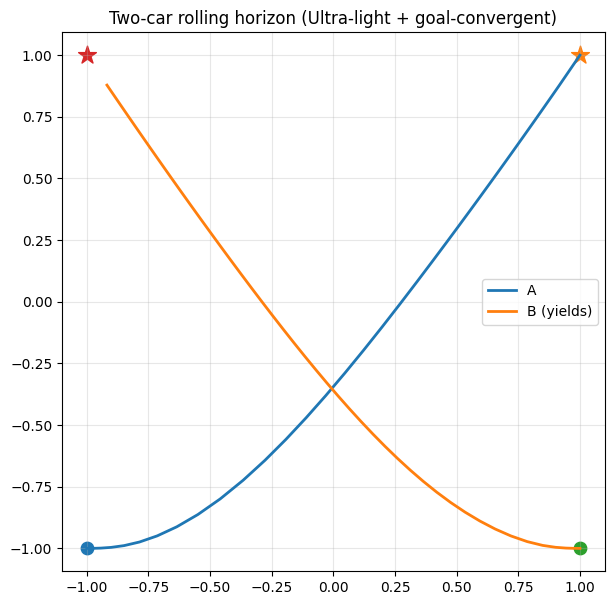

[A final] pos [1. 1.] dist 0.0
[B final] pos [-0.9180957  0.878699 ] dist 0.14636339247226715


In [13]:
# ===============================================================
# TWO-CAR Rolling Horizon (ULTRA-LIGHT + GOAL-CONVERGENT) — FULL CELL
# - Far: FM only (no proposal CBF)
# - Mid: light proposal CBF
# - Near: strong proposal CBF
# - Adaptive replan cadence (far slow, near fast)
# - Execute u0 = [a0, delta_rate0] from FM 5ch tokens (ch3,ch4 at token0)
# - Bicycle dynamics in WORLD: state=[x,y,theta,v,delta]
# - NO execution-layer CBF (only proposal CBF inside sampler)
#
# KEY FIXES (stop "circles"):
#   (1) Mix FM controls with Pure-Pursuit tracking (stabilizes heading)
#   (2) Scale FM control (important if you forgot denorm)
#   (3) Stuck detector: if not approaching goal -> increase tracking weight
#   (4) Near-goal: strong brake + reduce turning authority
# ===============================================================

import sys, math
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[device]", device)

# ===============================================================
# 0) Robust sampler loader (pick nearest sampler_5h.py)
# ===============================================================
def find_nearest_file(filename: str, start: Path, max_up=12):
    start = start.resolve()
    candidates = []
    p = start
    for _ in range(max_up):
        candidates += list(p.rglob(filename))
        p = p.parent
    if not candidates:
        raise FileNotFoundError(f"{filename} not found from {start}")
    # choose shortest string path as "nearest"
    candidates = sorted(candidates, key=lambda x: len(str(x)))
    return candidates[0]

sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())
print("[USING sampler]", sampler_path)

import importlib.util
spec = importlib.util.spec_from_file_location("sampler_mod", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_mod"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

# ===============================================================
# 1) Model must already be loaded
# ===============================================================
if "model_5ch" not in globals():
    raise RuntimeError("model_5ch must be loaded before this cell (load ckpt in previous cell).")
model_5ch = model_5ch.to(device).eval()

# ===============================================================
# 2) Hyperparams (FAST + stable)
# ===============================================================
dt_exec = 0.10

T_steps      = 30          # 🔥 faster
num_segments = 4           # 🔥 faster
total_time   = 1.0

MAX_STEPS = 260
goal_tol  = 0.15

# adaptive replan
REPLAN_FAR  = 10
REPLAN_MID  = 5
REPLAN_NEAR = 1

# vehicle
L = 0.35
v_max_A = 1.2
v_max_B = 0.7
v_floor = 0.06

delta_max = np.deg2rad(30.0)
a_max     = 1.2            # 🔥 smaller accel
r_max     = np.deg2rad(55) # 🔥 smaller steer-rate

ema_beta_u = 0.90

# IMPORTANT: FM control scaling (if controls are normalized, this saves you)
FM_A_SCALE = 0.25
FM_R_SCALE = 0.20

# ===============================================================
# 3) Adaptive distance thresholds for proposal CBF
# ===============================================================
SAFE_DIST_FAR  = 1.6
SAFE_DIST_NEAR = 0.9

BASE_CBF = dict(
    MASK_GATE=1.0,
    SUPPRESS_FRAC=0.0,
    RAMP_FRAC=0.10,
    max_corr_norm=3.0,
)

CBF_LIGHT  = dict(passes=1, extra_margin=0.05, alpha=8.0)
CBF_STRONG = dict(passes=5, extra_margin=0.12, alpha=18.0)

# ===============================================================
# 4) Canonical transform (world->canonical for other agent + goal)
# ===============================================================
def build_can_tf(x0, g):
    x0 = np.asarray(x0, np.float32).reshape(2)
    g  = np.asarray(g,  np.float32).reshape(2)
    gvec = g - x0
    dist = float(np.linalg.norm(gvec) + 1e-9)

    ex = (gvec / dist).reshape(2,1)
    ey = np.array([[-ex[1,0]],[ex[0,0]]], np.float32)
    R_cw = np.concatenate([ex, ey], axis=1)
    R_wc = R_cw.T

    def world_to_can(xy):
        xy = np.asarray(xy, np.float32).reshape(-1,2)
        return ((R_wc @ (xy - x0).T).T).astype(np.float32)

    start_can = np.array([0.0, 0.0], np.float32)
    goal_can  = np.array([dist, 0.0], np.float32)
    return world_to_can, start_can, goal_can

# ===============================================================
# 5) Noise init
# ===============================================================
def make_x0_noise_can(T, seed):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * 0.02
    x0[:,:,0] = 0.0
    return x0

# ===============================================================
# 6) Extract u0=[a0, r0] from FM tokens (and scale)
# ===============================================================
def extract_u0(x_can):
    a0 = float(x_can[3,0]) * FM_A_SCALE
    r0 = float(x_can[4,0]) * FM_R_SCALE
    a0 = float(np.clip(a0, -a_max, a_max))
    r0 = float(np.clip(r0, -r_max, r_max))
    return np.array([a0, r0], np.float32)

# ===============================================================
# 7) Bicycle dynamics
# ===============================================================
def wrap_pi(th):
    return (th + np.pi)%(2*np.pi)-np.pi

def bicycle_step(state, u, v_max):
    x,y,th,v,delta = state
    a,r = float(u[0]), float(u[1])

    v2 = float(np.clip(v + dt_exec*a, 0.0, v_max))
    if v2 < v_floor and abs(a) > 1e-4:
        v2 = v_floor

    delta2 = float(np.clip(delta + dt_exec*r, -delta_max, delta_max))

    th2 = float(wrap_pi(th + dt_exec*(v2/L)*math.tan(delta2)))
    x2  = float(x + dt_exec*v2*math.cos(th2))
    y2  = float(y + dt_exec*v2*math.sin(th2))
    return np.array([x2,y2,th2,v2,delta2], np.float32)

# ===============================================================
# 8) Pure-Pursuit tracking delta_des, and mix FM with tracking
# ===============================================================
def pure_pursuit_delta_des(state, goal, lookahead=0.9):
    x,y,th,v,delta = state
    gx,gy = float(goal[0]), float(goal[1])
    dx,dy = gx-x, gy-y
    d = float(math.hypot(dx,dy) + 1e-9)
    Ld = float(np.clip(d, 0.35, lookahead))
    alpha = wrap_pi(math.atan2(dy,dx) - th)
    kappa = 2.0 * math.sin(alpha) / max(1e-6, Ld)
    delta_des = math.atan(L * kappa)
    return float(np.clip(delta_des, -delta_max, delta_max))

def mix_fm_with_tracking(u_fm, state, goal, *, w_track):
    # tracking r makes delta -> delta_des
    delta_des = pure_pursuit_delta_des(state, goal, lookahead=0.9)
    r_track = (delta_des - float(state[4])) / dt_exec
    r_track = float(np.clip(r_track, -r_max, r_max))

    # tracking accel: set v_des proportional to distance
    d = float(np.linalg.norm(np.asarray(goal, np.float32) - np.asarray(state[:2], np.float32)))
    v_des = float(np.clip(0.9*d, 0.0, v_max_A))
    a_track = (v_des - float(state[3])) / dt_exec
    a_track = float(np.clip(a_track, -a_max, a_max))

    a = (1.0-w_track)*float(u_fm[0]) + w_track*a_track
    r = (1.0-w_track)*float(u_fm[1]) + w_track*r_track

    # near goal: brake + reduce turning
    if d < 0.45:
        a = min(a, -0.8)
        r *= 0.5

    return np.array([np.clip(a, -a_max, a_max), np.clip(r, -r_max, r_max)], np.float32)

# ===============================================================
# 9) Adaptive FM planner (proposal-level CBF only)
# ===============================================================
def fm_plan_one_step(state, goal, other_xy, seed, dist_AB):
    x_self = state[:2]
    world_to_can, start_can, goal_can = build_can_tf(x_self, goal)

    other_can = world_to_can(np.asarray(other_xy, np.float32).reshape(1,2))[0]
    ellipses = [{"center": other_can, "radius":0.45}]

    x0_noise = make_x0_noise_can(T_steps, seed)
    cond_vec = np.array([1,0,1,0,0], np.float32)

    if dist_AB > SAFE_DIST_FAR:
        use_cbf = False
        cbf_kwargs = None
    elif dist_AB > SAFE_DIST_NEAR:
        use_cbf = True
        cbf_kwargs = {**BASE_CBF, **CBF_LIGHT}
    else:
        use_cbf = True
        cbf_kwargs = {**BASE_CBF, **CBF_STRONG}

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method="euler",
        atol=1e-5,
        rtol=1e-5,
        x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=start_can,
        goal_xy_norm=goal_can,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
        use_cbf=use_cbf,

        goal_guidance_weight=0.65,
        goal_guidance_mode="tail",
    )

    return extract_u0(x_can), use_cbf

# ===============================================================
# 10) Rolling horizon helpers
# ===============================================================
def ema(u_new, u_prev):
    if u_prev is None:
        return u_new
    return (ema_beta_u*u_prev + (1-ema_beta_u)*u_new).astype(np.float32)

def choose_replan_every(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return REPLAN_FAR
    elif dist_AB > SAFE_DIST_NEAR:
        return REPLAN_MID
    else:
        return REPLAN_NEAR

# ===============================================================
# 11) Run scenario
# ===============================================================
xA0 = np.array([-1,-1],np.float32); gA = np.array([ 1, 1],np.float32)
xB0 = np.array([ 1,-1],np.float32); gB = np.array([-1, 1],np.float32)

sA = np.array([xA0[0],xA0[1],0.0,   0.0,0.0], np.float32)
sB = np.array([xB0[0],xB0[1],math.pi,0.0,0.0], np.float32)

trajA=[sA.copy()]
trajB=[sB.copy()]

prev_uA=None
prev_uB=None
uA_cached = np.zeros(2, np.float32)
uB_cached = np.zeros(2, np.float32)

cbf_used_count = 0
fm_call_count  = 0

# "stuck" detector
last_dA = float(np.linalg.norm(sA[:2]-gA))
last_dB = float(np.linalg.norm(sB[:2]-gB))
stuckA = 0
stuckB = 0

for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2]-gA))
    dB = float(np.linalg.norm(sB[:2]-gB))
    doneA = (dA < goal_tol)
    doneB = (dB < goal_tol)
    if doneA and doneB:
        print("[done] step", step)
        break

    dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
    REPLAN_EVERY = choose_replan_every(dist_AB)

    if step % REPLAN_EVERY == 0:
        if not doneA:
            uA_cached, use_cbf_A = fm_plan_one_step(sA, gA, sB[:2], 1000+step, dist_AB)
            fm_call_count += 1
            cbf_used_count += int(use_cbf_A)
        else:
            uA_cached = np.zeros(2, np.float32)

        if not doneB:
            uB_cached, use_cbf_B = fm_plan_one_step(sB, gB, sA[:2], 2000+step, dist_AB)
            fm_call_count += 1
            cbf_used_count += int(use_cbf_B)
        else:
            uB_cached = np.zeros(2, np.float32)

    # EMA
    uA_fm = ema(uA_cached, prev_uA)
    uB_fm = ema(uB_cached, prev_uB)

    # stuck update (if not approaching goal)
    stuckA = stuckA + 1 if dA > last_dA - 1e-3 else 0
    stuckB = stuckB + 1 if dB > last_dB - 1e-3 else 0
    last_dA, last_dB = dA, dB

    # tracking weight: default 0.70, if stuck -> 0.90 (force convergence)
    wA = 0.70 if stuckA < 8 else 0.90
    wB = 0.70 if stuckB < 8 else 0.90

    uA = mix_fm_with_tracking(uA_fm, sA, gA, w_track=wA)
    uB = mix_fm_with_tracking(uB_fm, sB, gB, w_track=wB)

    # execute
    if not doneA:
        sA = bicycle_step(sA, uA, v_max_A)
    else:
        sA[:2] = gA

    if not doneB:
        sB = bicycle_step(sB, uB, v_max_B)
    else:
        sB[:2] = gB

    trajA.append(sA.copy())
    trajB.append(sB.copy())
    prev_uA = uA.copy()
    prev_uB = uB.copy()

trajA = np.array(trajA)
trajB = np.array(trajB)

print(f"[stats] FM calls={fm_call_count} | proposal-CBF used={cbf_used_count}")

# ===============================================================
# 12) Plot
# ===============================================================
plt.figure(figsize=(7,7))
plt.plot(trajA[:,0],trajA[:,1],lw=2,label="A")
plt.plot(trajB[:,0],trajB[:,1],lw=2,label="B (yields)")
plt.scatter([xA0[0]],[xA0[1]],s=80)
plt.scatter([gA[0]],[gA[1]],marker="*",s=180)
plt.scatter([xB0[0]],[xB0[1]],s=80)
plt.scatter([gB[0]],[gB[1]],marker="*",s=180)
plt.axis("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.title("Two-car rolling horizon (Ultra-light + goal-convergent)")
plt.show()

print("[A final] pos", trajA[-1,:2], "dist", float(np.linalg.norm(trajA[-1,:2]-gA)))
print("[B final] pos", trajB[-1,:2], "dist", float(np.linalg.norm(trajB[-1,:2]-gB)))


[device] cuda
[USING sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[replan 0] uA=[-0.03093166  1.5707964 ] uB=[-0.02243529 -1.5707964 ] dA=2.828 dB=2.828 distAB=2.000
[replan 2] uA=[-0.03331488  1.5707964 ] uB=[-0.03631161 -1.5707964 ] dA=2.818 dB=2.818 distAB=1.977
[replan 4] uA=[-0.0352702  0.2639318] uB=[-0.03406398 -1.5707964 ] dA=2.807 dB=2.807 distAB=1.956
[stats] FM samples=2600 | proposal-CBF used in candidates=2120


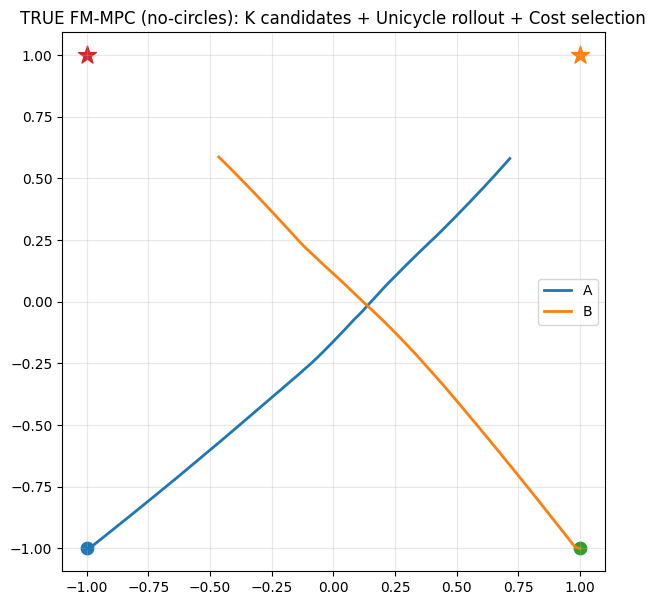

[A final] pos [0.71555257 0.5810189 ] dist 0.5064143538475037 v 0.16703468561172485
[B final] pos [-0.46446016  0.58732027] dist 0.6760972738265991 v 0.13674426078796387


In [13]:
# ===============================================================
# TRUE FM-MPC (K candidates) + Unicycle rollout + Cost selection  -- NO MORE CIRCLES
# Key fixes:
#   1) DO NOT treat token ch4 as true omega. Use it as a "turn command"
#      and convert to omega via heading-PD to goal direction.
#   2) Add progress penalty: must reduce distance-to-goal over horizon.
#   3) Keep everything else: K candidates, rollout H, pick best u0.
# ===============================================================

import sys, math
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[device]", device)

# ===============================================================
# 0) Robust sampler loader
# ===============================================================
def find_nearest_file(filename: str, start: Path, max_up=12):
    start = start.resolve()
    candidates = []
    p = start
    for _ in range(max_up):
        candidates += list(p.rglob(filename))
        p = p.parent
    if not candidates:
        raise FileNotFoundError(f"{filename} not found from {start}")
    candidates = sorted(candidates, key=lambda x: len(str(x)))
    return candidates[0]

sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())
print("[USING sampler]", sampler_path)

import importlib.util
spec = importlib.util.spec_from_file_location("sampler_mod", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_mod"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

# ===============================================================
# 1) Model must already be loaded
# ===============================================================
if "model_5ch" not in globals():
    raise RuntimeError("model_5ch must be loaded before this cell.")
model_5ch = model_5ch.to(device).eval()

control_scaler_can = globals().get("control_scaler_can", None)

# ===============================================================
# 2) MPC params
# ===============================================================
dt_exec = 0.10
T_steps      = 40
num_segments = 6
total_time   = 1.0
ode_method   = "euler"

H = 12
K = 10
MAX_STEPS = 260
goal_tol  = 0.15
REPLAN_EVERY = 2

# ===============================================================
# 3) Unicycle dynamics
# state: [x, y, theta, v]
# control: [a, omega]
# ===============================================================
v_max_A = 1.2
v_max_B = 0.7
v_min   = 0.0
v_floor = 0.06

a_max     = 1.6
omega_max = np.deg2rad(90)

def wrap_pi(th):
    return (th + np.pi)%(2*np.pi) - np.pi

def unicycle_step(state, u, *, dt, v_max):
    x, y, th, v = state
    a, omg = float(u[0]), float(u[1])

    a   = float(np.clip(a, -a_max, a_max))
    omg = float(np.clip(omg, -omega_max, omega_max))

    v2  = float(np.clip(v + dt*a, v_min, v_max))
    if v2 < v_floor and abs(a) > 1e-4:
        v2 = v_floor

    th2 = float(wrap_pi(th + dt*omg))
    x2  = float(x + dt*v2*math.cos(th2))
    y2  = float(y + dt*v2*math.sin(th2))
    return np.array([x2, y2, th2, v2], np.float32)

def rollout_unicycle(s0, a_seq, omg_seq, *, dt, v_max):
    Hh = int(len(a_seq))
    states = np.zeros((Hh+1, 4), np.float32)
    states[0] = s0
    for i in range(Hh):
        states[i+1] = unicycle_step(states[i], (a_seq[i], omg_seq[i]), dt=dt, v_max=v_max)
    return states[:, :2], states

# ===============================================================
# 4) Canonical transform for sampler
# ===============================================================
def build_can_tf(x0, g):
    x0 = np.asarray(x0, np.float32).reshape(2)
    g  = np.asarray(g,  np.float32).reshape(2)
    gvec = g - x0
    dist = float(np.linalg.norm(gvec) + 1e-9)

    ex = (gvec / dist).reshape(2,1)
    ey = np.array([[-ex[1,0]],[ex[0,0]]], np.float32)
    R_cw = np.concatenate([ex, ey], axis=1)
    R_wc = R_cw.T

    def world_to_can(xy):
        xy = np.asarray(xy, np.float32).reshape(-1,2)
        return ((R_wc @ (xy - x0).T).T).astype(np.float32)

    start_can = np.array([0.0, 0.0], np.float32)
    goal_can  = np.array([dist, 0.0], np.float32)
    return world_to_can, start_can, goal_can

def make_x0_noise_can(T, seed, scale=0.03):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * float(scale)
    x0[:,:,0] = 0.0
    return x0

# ===============================================================
# 5) Proposal-level CBF (optional)
# ===============================================================
SAFE_DIST_FAR  = 1.6
SAFE_DIST_NEAR = 0.9

BASE_CBF = dict(MASK_GATE=1.0, SUPPRESS_FRAC=0.0, RAMP_FRAC=0.10, max_corr_norm=3.0)
CBF_LIGHT  = dict(passes=1, extra_margin=0.05, alpha=10.0)
CBF_STRONG = dict(passes=6, extra_margin=0.14, alpha=22.0)

def choose_proposal_cbf(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, {**BASE_CBF, **CBF_LIGHT}
    else:
        return True, {**BASE_CBF, **CBF_STRONG}

# ===============================================================
# 6) Token -> controls
# IMPORTANT: ch4 is NOT trusted as omega. We use it as "turn command"
# and convert to omega via heading-PD to goal direction.
# ===============================================================
A_SCALE_A = 0.80
A_SCALE_B = 0.80

TURN_SCALE_A = 1.00   # scale for token-ch4 as turn command
TURN_SCALE_B = 1.00

K_TURN_P = 2.5        # heading PD gains (make it go to goal, not circles)
K_TURN_D = 0.4

def tokens_to_a_and_turn(a_tok, r_tok, *, a_scale, turn_scale):
    a_tok = a_tok.astype(np.float32)
    r_tok = r_tok.astype(np.float32)

    if control_scaler_can is not None:
        U = np.stack([a_tok, r_tok], axis=1)
        U = control_scaler_can.denormalize(U)
        a_tok = U[:,0].astype(np.float32)
        r_tok = U[:,1].astype(np.float32)

    a_seq   = (a_scale  * a_tok).astype(np.float32)
    turn_seq= (turn_scale * r_tok).astype(np.float32)

    a_seq   = np.clip(a_seq, -a_max, a_max).astype(np.float32)
    # turn_seq is NOT omega yet, do not clip to omega_max here
    return a_seq, turn_seq

def heading_pd_omega(states, goal_xy, turn_seq):
    """
    Convert turn command -> omega using heading error to goal direction.
    states: (H+1,4) during rollout; we will compute omega step-by-step online.
    Here we build omega_seq length H using current heading error + turn command.
    """
    goal_xy = np.asarray(goal_xy, np.float32)
    Hh = int(len(turn_seq))
    omega_seq = np.zeros((Hh,), np.float32)

    prev_err = 0.0
    for i in range(Hh):
        x,y,th,v = states[i]
        dx,dy = float(goal_xy[0]-x), float(goal_xy[1]-y)
        th_des = math.atan2(dy, dx)
        err = wrap_pi(th_des - float(th))

        # PD + token turn bias
        omg = K_TURN_P*err + K_TURN_D*(err - prev_err)/dt_exec + float(turn_seq[i])
        prev_err = err

        omega_seq[i] = float(np.clip(omg, -omega_max, omega_max))
    return omega_seq

# ===============================================================
# 7) FM sample candidate -> a_seq + omega_seq (via PD mapping)
# ===============================================================
def fm_sample_candidate(
    *,
    self_state,      # [x,y,th,v]
    goal_xy,
    other_xy,
    seed,
    a_scale,
    turn_scale,
    dist_AB,
    v_max_self,
):
    world_to_can, start_can, goal_can = build_can_tf(self_state[:2], goal_xy)
    other_can = world_to_can(np.asarray(other_xy, np.float32).reshape(1,2))[0]
    ellipses = [{"center": other_can, "radius":0.45}]

    use_cbf, cbf_kwargs = choose_proposal_cbf(dist_AB)
    x0_noise = make_x0_noise_can(T_steps, seed=seed, scale=0.03)
    cond_vec = np.array([1,0,1,0,0], np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method=ode_method,
        atol=1e-5, rtol=1e-5,
        x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=start_can,
        goal_xy_norm=goal_can,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
        use_cbf=use_cbf,
        goal_guidance_weight=0.55,
        goal_guidance_mode="tail",
    )

    Hh = int(min(H, x_can.shape[1]))
    a_tok = x_can[3, :Hh]
    r_tok = x_can[4, :Hh]   # treat as "turn command", NOT omega

    a_seq, turn_seq = tokens_to_a_and_turn(a_tok, r_tok, a_scale=a_scale, turn_scale=turn_scale)

    # build omega_seq using heading-PD mapping (needs a rollout of states; do a quick rollout with omega=0 first)
    # This is just to get states[i] for PD; then we will rollout again using omega_seq.
    pos0, st0 = rollout_unicycle(self_state, a_seq, np.zeros((Hh,),np.float32), dt=dt_exec, v_max=v_max_self)
    omega_seq = heading_pd_omega(st0, goal_xy, turn_seq)

    return a_seq, omega_seq, bool(use_cbf)

# ===============================================================
# 8) Cost with PROGRESS penalty (kills circles)
# ===============================================================
R_SAFE = 0.55
W_GOAL_END   = 10.0
W_GOAL_PATH  = 1.0
W_COLL       = 220.0
W_SMOOTH     = 0.25
W_SPEED_PREF = 0.08
W_PROGRESS   = 40.0     # ✅ key

def candidate_cost(pos_self, states_self, pos_other_pred, goal_xy, a_seq, omg_seq, d_now, v_pref=0.8):
    goal_xy = np.asarray(goal_xy, np.float32)

    d_end  = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos_self - goal_xy[None,:], axis=1)))

    d = np.linalg.norm(pos_self - pos_other_pred, axis=1)
    viol = np.clip(R_SAFE - d, 0.0, None)
    coll = float(np.sum(viol**2))

    da = np.diff(a_seq, prepend=a_seq[0])
    dw = np.diff(omg_seq, prepend=omg_seq[0])
    smooth = float(np.mean(da*da + 0.2*dw*dw))

    v_mean = float(np.mean(states_self[:,3]))
    speed_pref = float((v_pref - v_mean)**2)

    # progress: must get closer than current
    prog = max(0.0, d_end - (d_now - 1e-3))  # >0 means "not improved"
    return (
        W_GOAL_END   * d_end +
        W_GOAL_PATH  * d_path +
        W_COLL       * coll +
        W_SMOOTH     * smooth +
        W_SPEED_PREF * speed_pref +
        W_PROGRESS   * prog
    )

# ===============================================================
# 9) Predict other over horizon (constant last control)
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    a_seq = np.full((H,), float(other_u_last[0]), np.float32)
    w_seq = np.full((H,), float(other_u_last[1]), np.float32)
    pos, st = rollout_unicycle(other_state, a_seq, w_seq, dt=dt, v_max=v_max)
    return pos, st

# ===============================================================
# 10) MPC pick best u0
# ===============================================================
def mpc_pick_u0(
    *,
    self_state, self_goal,
    other_state, other_u_last,
    a_scale, turn_scale,
    v_max_self, v_max_other,
    seed_base,
):
    dist_AB = float(np.linalg.norm(self_state[:2] - other_state[:2]))
    pos_other_pred, _ = predict_other_traj(other_state, other_u_last, dt=dt_exec, v_max=v_max_other)

    d_now = float(np.linalg.norm(self_state[:2] - np.asarray(self_goal,np.float32)))

    best_J = None
    best_u0 = None
    cbf_cnt = 0

    for k in range(K):
        seed = int(seed_base + 97*k)

        a_seq, omg_seq, used_cbf = fm_sample_candidate(
            self_state=self_state,
            goal_xy=self_goal,
            other_xy=other_state[:2],
            seed=seed,
            a_scale=a_scale,
            turn_scale=turn_scale,
            dist_AB=dist_AB,
            v_max_self=v_max_self,
        )
        cbf_cnt += int(used_cbf)

        pos_self, st_self = rollout_unicycle(self_state, a_seq, omg_seq, dt=dt_exec, v_max=v_max_self)

        J = candidate_cost(pos_self, st_self, pos_other_pred, self_goal, a_seq, omg_seq, d_now, v_pref=0.8)

        u0 = np.array([float(a_seq[0]), float(omg_seq[0])], np.float32)
        if (best_J is None) or (J < best_J):
            best_J = J
            best_u0 = u0

    if best_u0 is None or (not np.all(np.isfinite(best_u0))):
        best_u0 = np.zeros(2, np.float32)
        best_J = float("inf")
    return best_u0, float(best_J), int(cbf_cnt), float(dist_AB)

# ===============================================================
# 11) Run scenario
# ===============================================================
xA0 = np.array([-1,-1],np.float32); gA = np.array([ 1, 1],np.float32)
xB0 = np.array([ 1,-1],np.float32); gB = np.array([-1, 1],np.float32)

sA = np.array([xA0[0], xA0[1], 0.0,     0.0], np.float32)
sB = np.array([xB0[0], xB0[1], math.pi, 0.0], np.float32)

trajA=[sA.copy()]
trajB=[sB.copy()]

uA_last=None
uB_last=None

fm_samples=0
cbf_used_total=0

for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = dA < goal_tol
    doneB = dB < goal_tol
    if doneA and doneB:
        print("[done] step", step)
        break

    if step % REPLAN_EVERY == 0:
        if not doneA:
            uA_last, JA, cbfA, distAB = mpc_pick_u0(
                self_state=sA, self_goal=gA,
                other_state=sB, other_u_last=uB_last,
                a_scale=A_SCALE_A, turn_scale=TURN_SCALE_A,
                v_max_self=v_max_A, v_max_other=v_max_B,
                seed_base=1000 + step*10,
            )
            fm_samples += K
            cbf_used_total += cbfA
        else:
            uA_last = np.zeros(2,np.float32)

        if not doneB:
            uB_last, JB, cbfB, distAB = mpc_pick_u0(
                self_state=sB, self_goal=gB,
                other_state=sA, other_u_last=uA_last,
                a_scale=A_SCALE_B, turn_scale=TURN_SCALE_B,
                v_max_self=v_max_B, v_max_other=v_max_A,
                seed_base=2000 + step*10,
            )
            fm_samples += K
            cbf_used_total += cbfB
        else:
            uB_last = np.zeros(2,np.float32)

        if step < 6:
            print(f"[replan {step}] uA={uA_last} uB={uB_last} dA={dA:.3f} dB={dB:.3f} distAB={float(np.linalg.norm(sA[:2]-sB[:2])):.3f}")

    if not doneA:
        sA = unicycle_step(sA, uA_last, dt=dt_exec, v_max=v_max_A)
    else:
        sA[:2] = gA

    if not doneB:
        sB = unicycle_step(sB, uB_last, dt=dt_exec, v_max=v_max_B)
    else:
        sB[:2] = gB

    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA=np.asarray(trajA,np.float32)
trajB=np.asarray(trajB,np.float32)

print(f"[stats] FM samples={fm_samples} | proposal-CBF used in candidates={cbf_used_total}")

plt.figure(figsize=(7,7))
plt.plot(trajA[:,0], trajA[:,1], lw=2, label="A")
plt.plot(trajB[:,0], trajB[:,1], lw=2, label="B")
plt.scatter([xA0[0]],[xA0[1]], s=80)
plt.scatter([gA[0]],[gA[1]], marker="*", s=180)
plt.scatter([xB0[0]],[xB0[1]], s=80)
plt.scatter([gB[0]],[gB[1]], marker="*", s=180)
plt.axis("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.title("TRUE FM-MPC (no-circles): K candidates + Unicycle rollout + Cost selection")
plt.show()

print("[A final] pos", trajA[-1,:2], "dist", float(np.linalg.norm(trajA[-1,:2]-gA)), "v", float(trajA[-1,3]))
print("[B final] pos", trajB[-1,:2], "dist", float(np.linalg.norm(trajB[-1,:2]-gB)), "v", float(trajB[-1,3]))


[Collision Check]
R_SAFE_CHECK = 0.550
T steps      = 261
min dist     = 0.1295  at step 218
❌ Collision steps: 63 steps
   first collision step = 173
   last  collision step = 235


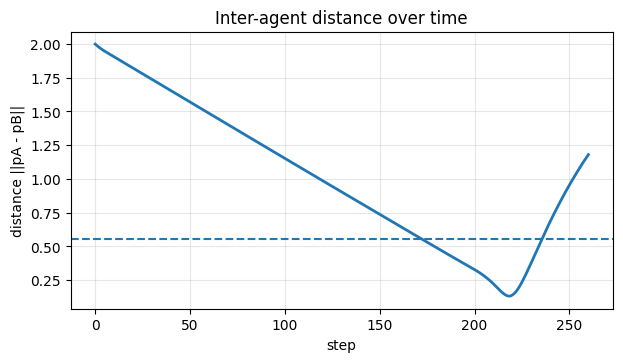

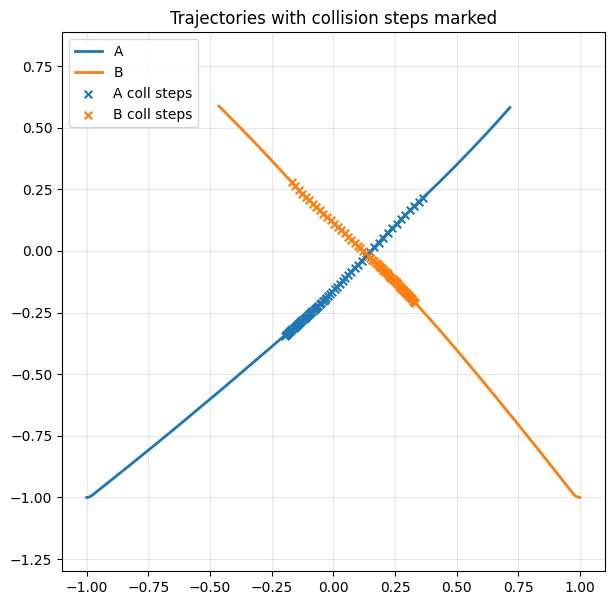

In [14]:
# ===============================================================
# COLLISION CHECK CELL (for TRUE FM-MPC trajectories)
# Expects: trajA, trajB already exist, each shape (T,4) with [:,0:2]=xy
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt

assert "trajA" in globals() and "trajB" in globals(), "trajA/trajB not found. Run your FM-MPC cell first."
assert trajA.shape[0] == trajB.shape[0], f"traj length mismatch: {trajA.shape} vs {trajB.shape}"

# --- choose your safety radius here (match your cost if you want) ---
R_SAFE_CHECK = 0.55   # you used R_SAFE ~0.55 in cost; keep consistent

A_xy = trajA[:, :2].astype(np.float32)
B_xy = trajB[:, :2].astype(np.float32)

d = np.linalg.norm(A_xy - B_xy, axis=1)            # (T,)
min_d = float(d.min())
t_min = int(d.argmin())

coll_mask = d < R_SAFE_CHECK
coll_steps = np.where(coll_mask)[0]
num_coll = int(coll_mask.sum())
first_coll = int(coll_steps[0]) if num_coll > 0 else None

print("================================================")
print("[Collision Check]")
print(f"R_SAFE_CHECK = {R_SAFE_CHECK:.3f}")
print(f"T steps      = {len(d)}")
print(f"min dist     = {min_d:.4f}  at step {t_min}")
if num_coll == 0:
    print("✅ No collision steps (d < R_SAFE_CHECK): NONE")
else:
    print(f"❌ Collision steps: {num_coll} steps")
    print(f"   first collision step = {first_coll}")
    print(f"   last  collision step = {int(coll_steps[-1])}")
print("================================================")

# ---- plot distance curve ----
plt.figure(figsize=(7,3.6))
plt.plot(d, lw=2)
plt.axhline(R_SAFE_CHECK, linestyle="--")
plt.grid(alpha=0.3)
plt.xlabel("step")
plt.ylabel("distance ||pA - pB||")
plt.title("Inter-agent distance over time")
plt.show()

# ---- plot traj with collision points marked ----
plt.figure(figsize=(7,7))
plt.plot(A_xy[:,0], A_xy[:,1], lw=2, label="A")
plt.plot(B_xy[:,0], B_xy[:,1], lw=2, label="B")

if num_coll > 0:
    plt.scatter(A_xy[coll_steps,0], A_xy[coll_steps,1], s=30, marker="x", label="A coll steps")
    plt.scatter(B_xy[coll_steps,0], B_xy[coll_steps,1], s=30, marker="x", label="B coll steps")

plt.axis("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.title("Trajectories with collision steps marked")
plt.show()


In [1]:
# ===============================================================
# FM-MPC: Two-Agent Collision Avoidance with Unicycle Dynamics
# 
# FM model outputs: [x, y, theta, a, delta_rate]
# - Channels 0,1: XY position (用于 path reference)
# - Channels 3,4: a (acceleration), delta_rate (转向率)
#
# 策略：
#   1. 每次 replan 调用 sampler_5h 生成新的轨迹
#   2. 用 FM 的 XY 轨迹做 path tracking -> unicycle controls
#   3. 只执行第一步 u0，下次 replan 重新采样
#   4. CBF 在 sampler 内部处理避障
# ===============================================================

import sys, math
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
def find_nearest_file(filename: str, start: Path, max_up=12):
    start = start.resolve()
    candidates = []
    p = start
    for _ in range(max_up):
        candidates += list(p.rglob(filename))
        p = p.parent
    if not candidates:
        raise FileNotFoundError(f"{filename} not found from {start}")
    return sorted(candidates, key=lambda x: len(str(x)))[0]

sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())
print(f"[sampler] {sampler_path}")

import importlib.util
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

# ===============================================================
# 1) Model check - model_5ch 必须已经加载
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
# Execution
dt_exec = 0.10

# FM sampler
T_steps      = 40
num_segments = 10
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

# MPC
H = 12              # horizon for tracking
K = 8               # candidates per replan
REPLAN_EVERY = 2
MAX_STEPS = 250
goal_tol = 0.15

# ===============================================================
# 3) Unicycle dynamics
# ===============================================================
v_max_A   = 1.0
v_max_B   = 0.6
v_min     = 0.0
v_floor   = 0.08
a_max     = 1.5
omega_max = np.deg2rad(120)

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def unicycle_step(s, u, *, dt, v_max):
    """
    s = [x, y, theta, v]
    u = [a, omega]
    """
    x, y, th, v = s
    a   = float(np.clip(u[0], -a_max, a_max))
    omg = float(np.clip(u[1], -omega_max, omega_max))
    
    v2 = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.01:
        v2 = v_floor
    
    th2 = wrap_pi(th + dt * omg)
    x2  = x + dt * v2 * math.cos(th2)
    y2  = y + dt * v2 * math.sin(th2)
    
    return np.array([x2, y2, th2, v2], dtype=np.float32)

def rollout_unicycle(s0, U, *, dt, v_max):
    """Rollout controls U (H,2) from s0, return positions (H+1,2) and states (H+1,4)"""
    Hh = U.shape[0]
    states = np.zeros((Hh+1, 4), dtype=np.float32)
    states[0] = s0
    for i in range(Hh):
        states[i+1] = unicycle_step(states[i], U[i], dt=dt, v_max=v_max)
    return states[:, :2], states

# ===============================================================
# 4) Canonical frame (SE2)
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    """
    Build SE2 transform: canonical frame has start at origin, goal on +x axis.
    Returns: world_to_can, can_to_world, start_can, goal_can, dist
    """
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy, np.float32).reshape(2)
    
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    
    cos_th = d[0] / dist
    sin_th = d[1] / dist
    
    # World -> Canonical rotation matrix
    R_wc = np.array([[cos_th, sin_th],
                     [-sin_th, cos_th]], dtype=np.float32)
    R_cw = R_wc.T  # Canonical -> World
    
    def world_to_can(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)
    
    def can_to_world(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)
    
    def world_to_can_angle(th_world):
        """Transform heading from world to canonical"""
        return wrap_pi(th_world - math.atan2(sin_th, cos_th))
    
    def can_to_world_angle(th_can):
        """Transform heading from canonical to world"""
        return wrap_pi(th_can + math.atan2(sin_th, cos_th))
    
    start_can = np.array([0.0, 0.0], np.float32)
    goal_can  = np.array([dist, 0.0], np.float32)
    
    return {
        'w2c': world_to_can,
        'c2w': can_to_world,
        'w2c_angle': world_to_can_angle,
        'c2w_angle': can_to_world_angle,
        'start_can': start_can,
        'goal_can': goal_can,
        'dist': dist,
        'R_wc': R_wc,
        'R_cw': R_cw,
    }

# ===============================================================
# 5) CBF settings
# ===============================================================
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 0.8

BASE_CBF = dict(MASK_GATE=1.0, SUPPRESS_FRAC=0.0, RAMP_FRAC=0.15, max_corr_norm=3.0)
CBF_LIGHT  = dict(passes=3, extra_margin=0.08, alpha=10.0)
CBF_STRONG = dict(passes=10, extra_margin=0.20, alpha=25.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, {**BASE_CBF, **CBF_LIGHT}
    else:
        return True, {**BASE_CBF, **CBF_STRONG}

# ===============================================================
# 6) FM trajectory sampling
# ===============================================================
def make_x0_noise(T, seed):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * noise_scale
    x0[:, :, 0] = 0.0  # anchor start point
    return x0

def sample_fm_trajectory(*, self_state, goal_xy, other_xy, seed):
    """
    Sample one FM trajectory.
    Returns: xy_world (T,2), theta_can (T,), used_cbf
    """
    self_xy = self_state[:2]
    
    # Build canonical frame
    tf = build_canonical_frame(self_xy, goal_xy)
    
    # Other agent in canonical frame
    other_can = tf['w2c'](other_xy.reshape(1, 2))[0]
    ellipses = [{"center": other_can.copy(), "radius": 0.45}]
    
    # CBF config based on distance
    dist_AB = float(np.linalg.norm(self_xy - other_xy))
    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    
    # Initial noise
    x0_noise = make_x0_noise(T_steps, seed)
    
    # Conditioning vector (adjust based on your training)
    cond_vec = np.array([1, 0, 1, 0, 0], dtype=np.float32)
    
    # Sample
    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method=ode_method,
        atol=1e-4,
        rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf['start_can'],
        goal_xy_norm=tf['goal_can'],
        start_guidance_weight=0.4,
        goal_guidance_weight=0.8,
        goal_guidance_mode="tail",
        lock_start=True,
        use_cbf=use_cbf,
        scaler=None,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
    )
    
    # x_can: (5, T) -> extract XY path in canonical frame
    xy_can = x_can[0:2, :].T.astype(np.float32)  # (T, 2) x_can从fm sampler模型中来的
    theta_can = x_can[2, :].astype(np.float32)    # (T,)
    
    # Transform to world frame
    xy_world = tf['c2w'](xy_can)  # (T, 2)
    
    return xy_world, theta_can, use_cbf, tf

# ===============================================================
# 7) Path tracking -> Unicycle controls from pure pursuit
# ===============================================================
def path_to_controls(s0, path_xy, *, H, dt, v_max, 
                     lookahead_ratio=0.15, k_omega=3.0, k_accel=2.0):
    """
    Pure-pursuit style tracking: path (T,2) -> controls (H,2)
    """
    T_path = path_xy.shape[0]
    
    # Resample path to H+1 points uniformly
    if T_path >= H + 1:
        indices = np.linspace(0, T_path - 1, H + 1).astype(int)
        ref = path_xy[indices]
    else:
        ref = np.zeros((H + 1, 2), dtype=np.float32)
        ref[:T_path] = path_xy
        ref[T_path:] = path_xy[-1]
    
    s = s0.copy()
    U = np.zeros((H, 2), dtype=np.float32)
    
    for i in range(H):
        x, y, th, v = s
        
        # Lookahead target
        look_idx = min(i + 1 + int(lookahead_ratio * H), H)
        target = ref[look_idx]
        
        dx = target[0] - x
        dy = target[1] - y
        dist = math.hypot(dx, dy)
        
        # Desired heading
        th_des = math.atan2(dy, dx)
        e_th = wrap_pi(th_des - th)
        
        # Omega (proportional to heading error)
        omega = float(np.clip(k_omega * e_th, -omega_max, omega_max))
        
        # Desired speed
        v_des = min(k_accel * dist / dt, v_max)
        
        # Slow down when turning sharply
        turn_penalty = max(0.25, 1.0 - 0.7 * abs(e_th) / np.pi)
        v_des *= turn_penalty
        
        # Acceleration
        a = float(np.clip(k_accel * (v_des - v), -a_max, a_max))
        
        U[i] = np.array([a, omega], dtype=np.float32)
        s = unicycle_step(s, U[i], dt=dt, v_max=v_max)
    
    return U, ref

# ===============================================================
# 8) Cost function
# ===============================================================
R_SAFE = 0.45

W_GOAL_END  = 12.0
W_GOAL_PATH = 1.0
W_COLL      = 250.0
W_SMOOTH    = 0.2
W_SPEED     = 0.05

def compute_cost(pos_self, states_self, pos_other_pred, goal_xy, U, v_pref):
    """Evaluate trajectory cost"""
    # Goal distance
    d_end  = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos_self - goal_xy, axis=1)))
    
    # Collision penalty
    d_inter = np.linalg.norm(pos_self - pos_other_pred, axis=1)
    violations = np.clip(R_SAFE - d_inter, 0.0, None)
    coll_cost = float(np.sum(violations ** 2))
    
    # Smoothness
    dU = np.diff(U, axis=0, prepend=U[0:1])
    smooth_cost = float(np.mean(dU[:, 0]**2 + 0.5 * dU[:, 1]**2))
    
    # Speed preference
    v_mean = float(np.mean(states_self[:, 3]))
    speed_cost = float((v_pref - v_mean) ** 2)
    
    return (W_GOAL_END * d_end + 
            W_GOAL_PATH * d_path + 
            W_COLL * coll_cost + 
            W_SMOOTH * smooth_cost + 
            W_SPEED * speed_cost)

# ===============================================================
# 9) Predict other agent (simple: use cached path or hold)
# ===============================================================
def predict_other_path(other_state, other_path_cache, *, H):
    """Predict other agent's future positions"""
    if other_path_cache is not None and len(other_path_cache) >= 2:
        T_path = other_path_cache.shape[0]
        if T_path >= H + 1:
            indices = np.linspace(0, T_path - 1, H + 1).astype(int)
            return other_path_cache[indices].astype(np.float32)
        else:
            pred = np.zeros((H + 1, 2), dtype=np.float32)
            pred[:T_path] = other_path_cache
            pred[T_path:] = other_path_cache[-1]
            return pred
    
    # Fallback: hold position
    return np.tile(other_state[:2], (H + 1, 1)).astype(np.float32)

# ===============================================================
# 10) MPC: sample K trajectories, pick best u0
# ===============================================================
def mpc_replan(*, self_state, goal_xy, other_state, other_path_cache,
               v_max_self, v_pref, seed_base):
    """
    Sample K FM trajectories, track each, evaluate cost, return best u0 and path.
    """
    pos_other_pred = predict_other_path(other_state, other_path_cache, H=H)
    
    best = None  # (cost, u0, path_xy, cbf_used)
    cbf_count = 0
    
    for k in range(K):
        seed = int(seed_base + 137 * k + 7919)
        
        try:
            path_xy, _, used_cbf, _ = sample_fm_trajectory(
                self_state=self_state,
                goal_xy=goal_xy,
                other_xy=other_state[:2],
                seed=seed,
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue
        
        cbf_count += int(used_cbf)
        
        # Track path to get controls
        U, ref = path_to_controls(
            self_state, path_xy,
            H=H, dt=dt_exec, v_max=v_max_self,
            lookahead_ratio=0.12, k_omega=2.8, k_accel=2.0
        )
        
        # Rollout
        pos_self, states_self = rollout_unicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        
        # Evaluate
        J = compute_cost(pos_self, states_self, pos_other_pred, goal_xy, U, v_pref)
        
        u0 = U[0].copy()
        
        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)
    
    if best is None:
        return np.zeros(2, dtype=np.float32), float('inf'), None, 0
    
    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) Scenario setup
# ===============================================================
# Cross scenario
xA0 = np.array([-1.2, -1.2], dtype=np.float32)
gA  = np.array([ 1.2,  1.2], dtype=np.float32)
xB0 = np.array([ 1.2, -1.2], dtype=np.float32)
gB  = np.array([-1.2,  1.2], dtype=np.float32)

# Initial heading toward goal
thA0 = float(math.atan2(gA[1] - xA0[1], gA[0] - xA0[0]))
thB0 = float(math.atan2(gB[1] - xB0[1], gB[0] - xB0[0]))

# Initial states [x, y, theta, v]
sA = np.array([xA0[0], xA0[1], thA0, 0.0], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0], dtype=np.float32)

# Trajectory history
trajA = [sA.copy()]
trajB = [sB.copy()]

# Last controls
uA = np.zeros(2, dtype=np.float32)
uB = np.zeros(2, dtype=np.float32)

# Cached paths for prediction
pathA_cache = None
pathB_cache = None

# Statistics
cbf_total = 0
replan_count = 0

print("=" * 60)
print("FM-MPC Simulation: Two-Agent Collision Avoidance")
print("=" * 60)
print(f"Agent A: {xA0} -> {gA}, v_max={v_max_A}")
print(f"Agent B: {xB0} -> {gB}, v_max={v_max_B}")
print(f"H={H}, K={K}, dt={dt_exec}, T_steps={T_steps}")
print("=" * 60)

# ===============================================================
# 12) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = dA < goal_tol
    doneB = dB < goal_tol
    
    if doneA and doneB:
        print(f"\n[DONE] Both agents reached goals at step {step}")
        break
    
    # Replan every REPLAN_EVERY steps
    if step % REPLAN_EVERY == 0:
        replan_count += 1
        
        # Agent A
        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                self_state=sA,
                goal_xy=gA,
                other_state=sB,
                other_path_cache=pathB_cache,
                v_max_self=v_max_A,
                v_pref=0.6,
                seed_base=1000 + step * 31,
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, dtype=np.float32)
            pathA_cache = None
        
        # Agent B
        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                self_state=sB,
                goal_xy=gB,
                other_state=sA,
                other_path_cache=pathA_cache,
                v_max_self=v_max_B,
                v_pref=0.4,
                seed_base=2000 + step * 37,
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, dtype=np.float32)
            pathB_cache = None
        
        # Debug print
        if step < 20 or step % 20 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[step {step:3d}] dA={dA:.3f} dB={dB:.3f} dist_AB={dist_AB:.3f} "
                  f"uA=[{uA[0]:+.2f},{uA[1]:+.2f}] uB=[{uB[0]:+.2f},{uB[1]:+.2f}]")
    
    # Execute one step
    if not doneA:
        sA = unicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = unicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)
    
    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.array(trajA, dtype=np.float32)
trajB = np.array(trajB, dtype=np.float32)

print(f"\n[stats] replans={replan_count} | FM samples={replan_count * K * 2} | CBF used={cbf_total}")

# ===============================================================
# 13) Collision analysis
# ===============================================================
dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_mask = dist_AB < R_SAFE
coll_steps = np.where(coll_mask)[0]

print(f"[collision] min_dist={dist_AB.min():.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

# ===============================================================
# 14) Visualization
# ===============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Trajectories
ax = axes[0]
ax.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2, label='Agent A')
ax.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2, label='Agent B')

# Start/Goal markers
ax.scatter([xA0[0]], [xA0[1]], c='blue', s=100, marker='o', edgecolors='black', zorder=5)
ax.scatter([gA[0]], [gA[1]], c='blue', s=200, marker='*', edgecolors='black', zorder=5)
ax.scatter([xB0[0]], [xB0[1]], c='red', s=100, marker='o', edgecolors='black', zorder=5)
ax.scatter([gB[0]], [gB[1]], c='red', s=200, marker='*', edgecolors='black', zorder=5)

# Collision markers
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps, 0], trajA[coll_steps, 1], 
               c='black', s=40, marker='x', label='Collision')

# Safety circles at a few time steps
for t in range(0, len(trajA), max(1, len(trajA)//8)):
    circle = plt.Circle(trajA[t, :2], R_SAFE/2, fill=False, color='blue', alpha=0.3, ls='--')
    ax.add_patch(circle)
    circle = plt.Circle(trajB[t, :2], R_SAFE/2, fill=False, color='red', alpha=0.3, ls='--')
    ax.add_patch(circle)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend()
ax.set_title('FM-MPC: Two-Agent Trajectories')

# Right: Inter-agent distance over time
ax2 = axes[1]
time_axis = np.arange(len(dist_AB)) * dt_exec
ax2.plot(time_axis, dist_AB, 'k-', lw=2)
ax2.axhline(R_SAFE, color='r', ls='--', label=f'R_safe={R_SAFE}')
ax2.fill_between(time_axis, 0, R_SAFE, alpha=0.2, color='red')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Inter-agent Distance')
ax2.set_title('Distance Between Agents')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

[device] cuda
[sampler] D:\projects\sampler_5h.py


ModuleNotFoundError: No module named 'dmpc_fm_cbf'

[device] cuda
[USING sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py

[Initial] A: pos=[-1. -1.], theta=45.0°, goal=[1. 1.]
[Initial] B: pos=[ 1. -1.], theta=135.0°, goal=[-1.  1.]

[FM DEBUG] x_can shape: (5, 40)
  ch0 (x):         [-0.066, 3.671]
  ch1 (y):         [-0.273, 0.424]
  ch2 (theta):     [-0.218, 0.314]
  ch3 (a):         [-1.102, 1.210]
  ch4 (delta_rate):[-0.777, 0.218]
  goal_can: [2.828427 0.      ], start_can: [0. 0.]
  angle_offset: 45.0°
  controls_norm shape: (40, 2)
  theta_can[:10]: [ 0.07937945  0.10839997  0.09351891  0.1732184   0.26790714  0.09731454
  0.2065861   0.07617358  0.10466251 -0.00825539]
[step   0] uA=[+0.048, +1.571]  uB=[+0.050, +1.571]  dA=2.828 dB=2.828  dist_AB=2.000
[step   2] uA=[+0.039, -0.295]  uB=[+0.044, +1.571]  dA=2.816 dB=2.816  dist_AB=1.983
[step   4] uA=[+0.049, +1.571]  uB=[+0.055, +1.571]  dA=2.803 dB=2.804  dist_AB=1.962
[step   6] uA=[+0.050, +1.571]  uB=[+0.050, +1.571]  dA=2.789 dB=2.794  dist_AB=1.941
[s

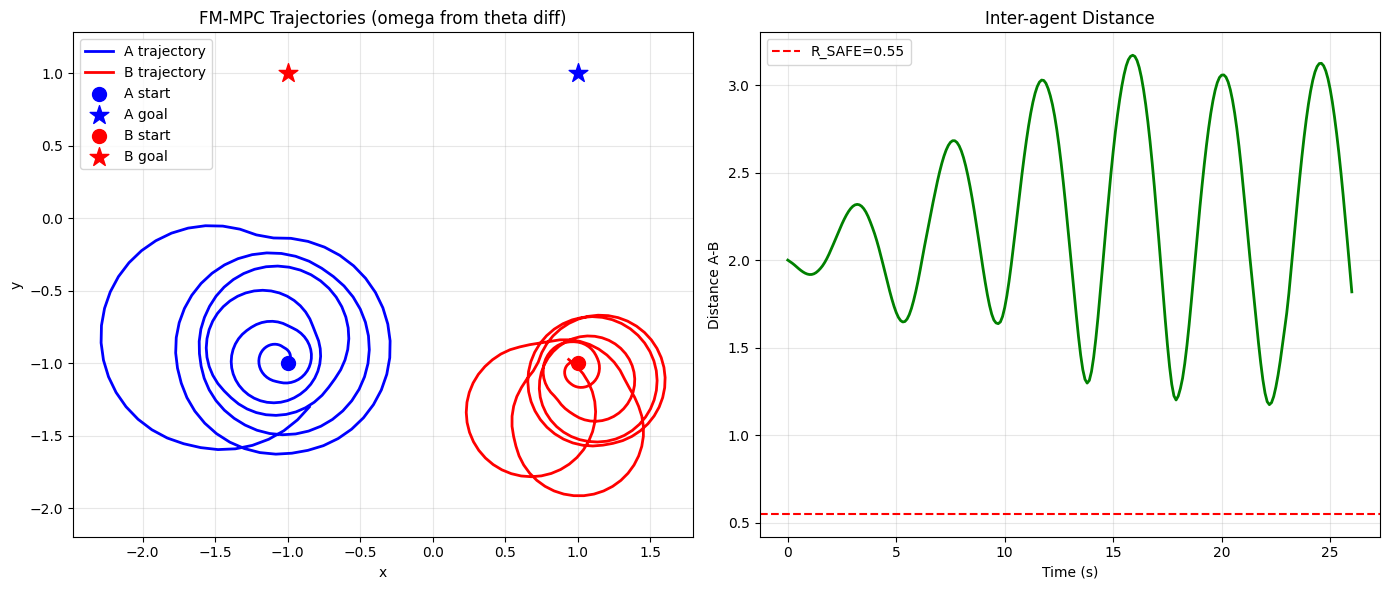


[A final] pos=[-0.8519443 -1.3007787], dist_to_goal=2.9535, v=1.200
[B final] pos=[ 0.93681663 -0.97277284], dist_to_goal=2.7646, v=0.700
[Safety] Minimum distance between A and B: 1.1738 (R_SAFE=0.55)
  ✅ No collision


In [ ]:
# ===============================================================
# TRUE FM-MPC (K candidates) + Unicycle rollout (H steps) + Cost selection
# ✅ 修复：从 theta (ch2) 差分计算 omega
# ✅ 修复：从 controls_norm[:,0] 取加速度 a
# ✅ 你的 5 通道: (x, y, theta, a, delta_rate)
#    - delta_rate 不能直接用于 unicycle
#    - 所以 omega = d(theta)/dt
# ===============================================================

import sys, math
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[device]", device)

# ===============================================================
# 0) Robust sampler loader
# ===============================================================
def find_nearest_file(filename: str, start: Path, max_up=12):
    start = start.resolve()
    candidates = []
    p = start
    for _ in range(max_up):
        candidates += list(p.rglob(filename))
        p = p.parent
    if not candidates:
        raise FileNotFoundError(f"{filename} not found from {start}")
    candidates = sorted(candidates, key=lambda x: len(str(x)))
    return candidates[0]

sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())
print("[USING sampler]", sampler_path)

import importlib.util
spec = importlib.util.spec_from_file_location("sampler_mod", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_mod"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

# ===============================================================
# 1) Model must already be loaded in previous cell
# ===============================================================
if "model_5ch" not in globals():
    raise RuntimeError("model_5ch must be loaded before this cell.")
model_5ch = model_5ch.to(device).eval()

# ===============================================================
# 2) Core MPC params
# ===============================================================
dt_exec = 0.10

# FM token length & ODE sampling budget
T_steps      = 40
num_segments = 6
total_time   = 1.0
ode_method   = "euler"

# MPC horizon & candidates
H = 12
K = 10

MAX_STEPS = 260
goal_tol  = 0.15

REPLAN_EVERY = 2

# ===============================================================
# 3) Unicycle model
# state: [x, y, theta, v]
# control: [a, omega]
# ===============================================================
v_max_A = 1.2
v_max_B = 0.7
v_min   = 0.0
v_floor = 0.06

a_max     = 1.6
omega_max = np.deg2rad(90)  # 1.57 rad/s

def wrap_pi(th):
    """Wrap angle to [-pi, pi]"""
    return (th + np.pi) % (2 * np.pi) - np.pi

def unicycle_step(state, u, *, dt, v_max):
    """Unicycle dynamics: state = [x, y, theta, v], u = [a, omega]"""
    x, y, th, v = state
    a, omg = float(u[0]), float(u[1])
    
    a   = float(np.clip(a, -a_max, a_max))
    omg = float(np.clip(omg, -omega_max, omega_max))
    
    v2  = float(np.clip(v + dt * a, v_min, v_max))
    
    # v_floor: prevent stuck at v=0
    if v2 < v_floor and abs(a) > 1e-4:
        v2 = v_floor
    
    th2 = float(wrap_pi(th + dt * omg))
    x2  = float(x + dt * v2 * math.cos(th2))
    y2  = float(y + dt * v2 * math.sin(th2))
    return np.array([x2, y2, th2, v2], np.float32)

def rollout_unicycle(s0, a_seq, omg_seq, *, dt, v_max):
    """Rollout unicycle for H steps"""
    Hh = int(len(a_seq))
    states = np.zeros((Hh + 1, 4), np.float32)
    states[0] = s0
    for i in range(Hh):
        states[i + 1] = unicycle_step(states[i], (a_seq[i], omg_seq[i]), dt=dt, v_max=v_max)
    return states[:, :2], states

# ===============================================================
# 4) Canonical transform for sampler
# ===============================================================
def build_can_tf(x0, g):
    """Build canonical frame transform: start at origin, goal on +x axis"""
    x0 = np.asarray(x0, np.float32).reshape(2)
    g  = np.asarray(g,  np.float32).reshape(2)
    gvec = g - x0
    dist = float(np.linalg.norm(gvec) + 1e-9)
    
    # Rotation matrix: world -> canonical
    ex = (gvec / dist).reshape(2, 1)
    ey = np.array([[-ex[1, 0]], [ex[0, 0]]], np.float32)
    R_cw = np.concatenate([ex, ey], axis=1)  # canonical basis in world coords
    R_wc = R_cw.T  # world -> canonical
    
    # 计算 world frame 到 canonical frame 的角度偏移
    angle_offset = float(np.arctan2(gvec[1], gvec[0]))
    
    def world_to_can(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((R_wc @ (xy - x0).T).T).astype(np.float32)
    
    def can_to_world(xy_can):
        xy_can = np.asarray(xy_can, np.float32).reshape(-1, 2)
        return ((R_cw @ xy_can.T).T + x0).astype(np.float32)
    
    start_can = np.array([0.0, 0.0], np.float32)
    goal_can  = np.array([dist, 0.0], np.float32)
    
    return {
        'w2c': world_to_can,
        'c2w': can_to_world,
        'start_can': start_can,
        'goal_can': goal_can,
        'angle_offset': angle_offset,
        'R_cw': R_cw,
        'R_wc': R_wc,
    }

def make_x0_noise_can(T, seed, scale=0.03):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(scale)
    x0[:, :, 0] = 0.0
    return x0

# ===============================================================
# 5) Proposal-level CBF (optional, only near)
# ===============================================================
SAFE_DIST_FAR  = 1.6
SAFE_DIST_NEAR = 0.9

BASE_CBF = dict(
    MASK_GATE=1.0,
    SUPPRESS_FRAC=0.0,
    RAMP_FRAC=0.10,
    max_corr_norm=3.0,
)
CBF_LIGHT  = dict(passes=1, extra_margin=0.05, alpha=10.0)
CBF_STRONG = dict(passes=6, extra_margin=0.14, alpha=22.0)

def choose_proposal_cbf(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, {**BASE_CBF, **CBF_LIGHT}
    else:
        return True, {**BASE_CBF, **CBF_STRONG}

# ===============================================================
# 6) 从 FM 输出提取控制量
#    - a: 从 controls_norm[:,0] 或 x_can[3,:]
#    - omega: 从 theta (x_can[2,:]) 差分计算
# ===============================================================
def extract_controls_from_fm(x_can, controls_norm, H, dt_fm, tf):
    """
    从 FM 输出提取 unicycle 控制量 (a, omega)
    
    你的 5 通道: (x, y, theta, a, delta_rate)
    - a 直接可用
    - delta_rate 不能直接用于 unicycle，需要从 theta 差分得到 omega
    
    Args:
        x_can: (5, T) FM 生成的轨迹
        controls_norm: (T, 2) 或 (2, T) 控制量 [a, delta_rate]
        H: horizon length
        dt_fm: FM 轨迹的时间步长
        tf: canonical transform dict (包含 angle_offset)
    
    Returns:
        a_seq: (H,) 加速度
        omega_seq: (H,) 角速度 (for unicycle)
        source: str 标识控制量来源
    """
    T_traj = x_can.shape[1]
    
    # ========== 1. 提取加速度 a ==========
    if controls_norm is not None:
        ctrl = np.asarray(controls_norm, dtype=np.float32)
        if ctrl.shape[0] == 2:
            a_raw = ctrl[0, :]  # (T,)
        elif ctrl.shape[1] == 2:
            a_raw = ctrl[:, 0]  # (T,)
        else:
            a_raw = x_can[3, :]
    else:
        a_raw = x_can[3, :]
    
    # ========== 2. 从 theta 差分计算 omega ==========
    # theta_can 是在 canonical frame 下的航向角
    theta_can = x_can[2, :].astype(np.float32)  # (T,)
    
    # 差分计算角速度
    dtheta = np.zeros_like(theta_can)
    for i in range(1, len(theta_can)):
        dtheta[i] = wrap_pi(theta_can[i] - theta_can[i-1])
    dtheta[0] = dtheta[1] if len(dtheta) > 1 else 0.0
    
    omega_raw = dtheta / dt_fm  # (T,)
    
    # ========== 3. 提取 H 步控制量 ==========
    # 跳过第 0 步（可能是静止状态）
    start_idx = 1
    end_idx = min(start_idx + H, T_traj)
    Hh = end_idx - start_idx
    
    a_seq = a_raw[start_idx:end_idx].astype(np.float32)
    omega_seq = omega_raw[start_idx:end_idx].astype(np.float32)
    
    # ========== 4. Clip to limits ==========
    a_seq = np.clip(a_seq, -a_max, a_max)
    omega_seq = np.clip(omega_seq, -omega_max, omega_max)
    
    # ========== 5. Pad if needed ==========
    if Hh < H:
        a_seq = np.pad(a_seq, (0, H - Hh), mode='edge')
        omega_seq = np.pad(omega_seq, (0, H - Hh), mode='edge')
    
    return a_seq, omega_seq, "a_from_ctrl_omega_from_theta_diff"

# ===============================================================
# 7) Sample ONE candidate from FM
# ===============================================================
DEBUG_FIRST_SAMPLE = True

def fm_sample_candidate(
    *,
    state_xy,
    goal_xy,
    other_xy,
    seed,
    dist_AB,
    debug=False,
):
    global DEBUG_FIRST_SAMPLE
    
    tf = build_can_tf(state_xy, goal_xy)
    
    other_can = tf['w2c'](np.asarray(other_xy, np.float32).reshape(1, 2))[0]
    ellipses = [{"center": other_can, "radius": 0.45}]
    
    use_cbf, cbf_kwargs = choose_proposal_cbf(dist_AB)
    
    x0_noise = make_x0_noise_can(T_steps, seed=seed, scale=0.03)
    cond_vec = np.array([1, 0, 1, 0, 0], np.float32)
    
    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method=ode_method,
        atol=1e-5,
        rtol=1e-5,
        x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf['start_can'],
        goal_xy_norm=tf['goal_can'],
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
        use_cbf=use_cbf,
        goal_guidance_weight=0.55,
        goal_guidance_mode="tail",
    )
    
    # Debug 输出（只打印第一次）
    if DEBUG_FIRST_SAMPLE:
        print(f"\n[FM DEBUG] x_can shape: {x_can.shape}")
        print(f"  ch0 (x):         [{x_can[0].min():.3f}, {x_can[0].max():.3f}]")
        print(f"  ch1 (y):         [{x_can[1].min():.3f}, {x_can[1].max():.3f}]")
        print(f"  ch2 (theta):     [{x_can[2].min():.3f}, {x_can[2].max():.3f}]")
        print(f"  ch3 (a):         [{x_can[3].min():.3f}, {x_can[3].max():.3f}]")
        print(f"  ch4 (delta_rate):[{x_can[4].min():.3f}, {x_can[4].max():.3f}]")
        print(f"  goal_can: {tf['goal_can']}, start_can: {tf['start_can']}")
        print(f"  angle_offset: {np.rad2deg(tf['angle_offset']):.1f}°")
        
        if controls_norm is not None:
            ctrl = np.asarray(controls_norm)
            print(f"  controls_norm shape: {ctrl.shape}")
        
        # 显示 theta 的前几步
        print(f"  theta_can[:10]: {x_can[2, :10]}")
        DEBUG_FIRST_SAMPLE = False
    
    # 提取控制量
    dt_fm = total_time / T_steps
    a_seq, omega_seq, source = extract_controls_from_fm(x_can, controls_norm, H, dt_fm, tf)
    
    if debug or (DEBUG_FIRST_SAMPLE == False and np.random.rand() < 0.01):
        print(f"  [Source: {source}] a[:3]={a_seq[:3]}, omega[:3]={omega_seq[:3]}")
    
    return a_seq, omega_seq, bool(use_cbf)

# ===============================================================
# 8) Cost function for candidate rollout
# ===============================================================
R_SAFE = 0.55

W_GOAL_END   = 10.0
W_GOAL_PATH  = 1.0
W_COLL       = 220.0
W_SMOOTH     = 0.25
W_SPEED_PREF = 0.08

def candidate_cost(
    pos_self,
    states_self,
    pos_other_pred,
    goal_xy,
    a_seq, omg_seq,
    *,
    v_pref=0.8,
):
    goal_xy = np.asarray(goal_xy, np.float32)
    
    d_end  = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos_self - goal_xy[None, :], axis=1)))
    
    d = np.linalg.norm(pos_self - pos_other_pred, axis=1)
    viol = np.clip(R_SAFE - d, 0.0, None)
    coll = float(np.sum(viol**2))
    
    da = np.diff(a_seq, prepend=a_seq[0])
    dw = np.diff(omg_seq, prepend=omg_seq[0])
    smooth = float(np.mean(da*da + 0.2*dw*dw))
    
    v_mean = float(np.mean(states_self[:, 3]))
    speed_pref = float((v_pref - v_mean)**2)
    
    return (
        W_GOAL_END   * d_end +
        W_GOAL_PATH  * d_path +
        W_COLL       * coll +
        W_SMOOTH     * smooth +
        W_SPEED_PREF * speed_pref
    )

# ===============================================================
# 9) Predict other agent over horizon
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    a_seq = np.full((H,), float(other_u_last[0]), np.float32)
    w_seq = np.full((H,), float(other_u_last[1]), np.float32)
    pos, st = rollout_unicycle(other_state, a_seq, w_seq, dt=dt, v_max=v_max)
    return pos, st

# ===============================================================
# 10) MPC pick: sample K, rollout H, pick best u0
# ===============================================================
def mpc_pick_u0(
    *,
    self_state, self_goal,
    other_state, other_u_last,
    v_max_self, v_max_other,
    seed_base,
):
    dist_AB = float(np.linalg.norm(self_state[:2] - other_state[:2]))
    pos_other_pred, _ = predict_other_traj(other_state, other_u_last, dt=dt_exec, v_max=v_max_other)
    
    best_J = None
    best_u0 = None
    use_cbf_count = 0
    
    for k in range(K):
        seed = int(seed_base + 97 * k)
        
        a_seq, omg_seq, used_cbf = fm_sample_candidate(
            state_xy=self_state[:2],
            goal_xy=self_goal,
            other_xy=other_state[:2],
            seed=seed,
            dist_AB=dist_AB,
        )
        use_cbf_count += int(used_cbf)
        
        pos_self, st_self = rollout_unicycle(self_state, a_seq, omg_seq, dt=dt_exec, v_max=v_max_self)
        
        J = candidate_cost(
            pos_self, st_self,
            pos_other_pred,
            np.asarray(self_goal, np.float32),
            a_seq, omg_seq,
            v_pref=0.8,
        )
        
        if (best_J is None) or (J < best_J):
            best_J = J
            best_u0 = np.array([float(a_seq[0]), float(omg_seq[0])], np.float32)
    
    # Fallback safety
    if best_u0 is None or (not np.all(np.isfinite(best_u0))):
        best_u0 = np.zeros(2, np.float32)
        best_J = float("inf")
    
    return best_u0, float(best_J), int(use_cbf_count), float(dist_AB)

# ===============================================================
# 11) Run two-car scenario
# ===============================================================
xA0 = np.array([-1, -1], np.float32); gA = np.array([1, 1], np.float32)
xB0 = np.array([1, -1], np.float32);  gB = np.array([-1, 1], np.float32)

# unicycle states: [x, y, theta, v]
# 初始航向指向目标
theta_A0 = math.atan2(gA[1] - xA0[1], gA[0] - xA0[0])
theta_B0 = math.atan2(gB[1] - xB0[1], gB[0] - xB0[0])

sA = np.array([xA0[0], xA0[1], theta_A0, 0.0], np.float32)
sB = np.array([xB0[0], xB0[1], theta_B0, 0.0], np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]

uA_last = None
uB_last = None

fm_samples = 0
cbf_used_total = 0

print(f"\n[Initial] A: pos={sA[:2]}, theta={np.rad2deg(sA[2]):.1f}°, goal={gA}")
print(f"[Initial] B: pos={sB[:2]}, theta={np.rad2deg(sB[2]):.1f}°, goal={gB}")

for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = dA < goal_tol
    doneB = dB < goal_tol
    if doneA and doneB:
        print(f"[done] step {step}")
        break
    
    if step % REPLAN_EVERY == 0:
        if not doneA:
            uA_last, JA, cbfA, distAB_A = mpc_pick_u0(
                self_state=sA, self_goal=gA,
                other_state=sB, other_u_last=uB_last,
                v_max_self=v_max_A, v_max_other=v_max_B,
                seed_base=1000 + step * 10,
            )
            fm_samples += K
            cbf_used_total += cbfA
        else:
            uA_last = np.zeros(2, np.float32)
        
        if not doneB:
            uB_last, JB, cbfB, distAB_B = mpc_pick_u0(
                self_state=sB, self_goal=gB,
                other_state=sA, other_u_last=uA_last,
                v_max_self=v_max_B, v_max_other=v_max_A,
                seed_base=2000 + step * 10,
            )
            fm_samples += K
            cbf_used_total += cbfB
        else:
            uB_last = np.zeros(2, np.float32)
        
        # Debug output
        if step < 20 or step % 20 == 0:
            print(f"[step {step:3d}] uA=[{uA_last[0]:+.3f}, {uA_last[1]:+.3f}]  "
                  f"uB=[{uB_last[0]:+.3f}, {uB_last[1]:+.3f}]  "
                  f"dA={dA:.3f} dB={dB:.3f}  dist_AB={float(np.linalg.norm(sA[:2]-sB[:2])):.3f}")
    
    # Execute one step
    if not doneA:
        sA = unicycle_step(sA, uA_last, dt=dt_exec, v_max=v_max_A)
    else:
        sA[:2] = gA
    
    if not doneB:
        sB = unicycle_step(sB, uB_last, dt=dt_exec, v_max=v_max_B)
    else:
        sB[:2] = gB
    
    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)

print(f"\n[stats] FM samples={fm_samples} | CBF used={cbf_used_total} | REPLAN_EVERY={REPLAN_EVERY}")

# ===============================================================
# 12) Plot
# ===============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: trajectory
ax1 = axes[0]
ax1.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2, label="A trajectory")
ax1.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2, label="B trajectory")
ax1.scatter([xA0[0]], [xA0[1]], c='blue', s=100, marker='o', label="A start", zorder=5)
ax1.scatter([gA[0]], [gA[1]], c='blue', s=200, marker='*', label="A goal", zorder=5)
ax1.scatter([xB0[0]], [xB0[1]], c='red', s=100, marker='o', label="B start", zorder=5)
ax1.scatter([gB[0]], [gB[1]], c='red', s=200, marker='*', label="B goal", zorder=5)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.axis("equal")
ax1.grid(alpha=0.3)
ax1.legend(loc='upper left')
ax1.set_title("FM-MPC Trajectories (omega from theta diff)")

# Right: inter-agent distance over time
ax2 = axes[1]
dist_AB_over_time = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
time_axis = np.arange(len(dist_AB_over_time)) * dt_exec
ax2.plot(time_axis, dist_AB_over_time, 'g-', lw=2)
ax2.axhline(y=R_SAFE, color='r', linestyle='--', label=f'R_SAFE={R_SAFE}')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Distance A-B")
ax2.grid(alpha=0.3)
ax2.legend()
ax2.set_title("Inter-agent Distance")

plt.tight_layout()
plt.show()

print(f"\n[A final] pos={trajA[-1, :2]}, dist_to_goal={float(np.linalg.norm(trajA[-1, :2] - gA)):.4f}, v={trajA[-1, 3]:.3f}")
print(f"[B final] pos={trajB[-1, :2]}, dist_to_goal={float(np.linalg.norm(trajB[-1, :2] - gB)):.4f}, v={trajB[-1, 3]:.3f}")

# Check minimum distance
min_dist = dist_AB_over_time.min()
print(f"[Safety] Minimum distance between A and B: {min_dist:.4f} (R_SAFE={R_SAFE})")
if min_dist < R_SAFE:
    print("  ⚠️ WARNING: Collision occurred!")
else:
    print("  ✅ No collision")

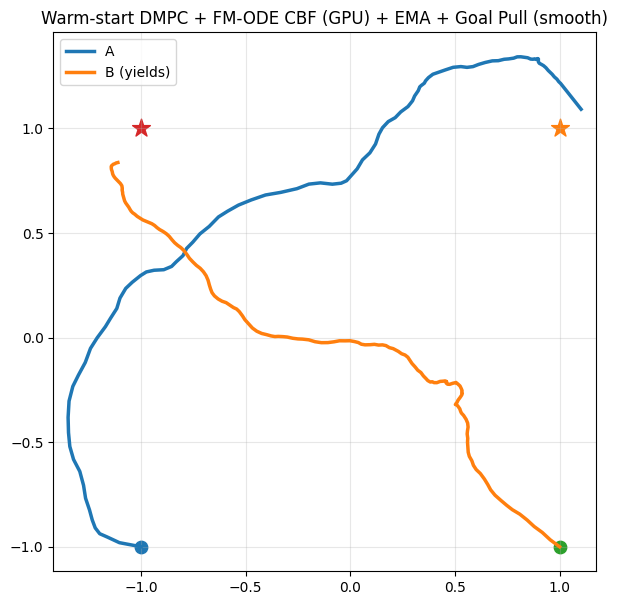

In [52]:
# ===============================================================
# FINAL CELL (SMOOTH) — GPU-friendly version (REFACTORED)
# Warm-start DMPC (K=1)
# FM ODE with CBF INSIDE (first-step only)
# + EMA smoothing
# + Goal-pull (soft heading correction)
#
# Key speed fixes (borrow JAX-style ideas):
#   ✅ keep everything as pure tensor ops on device (avoid CPU ping-pong)
#   ✅ NO torch.tensor(...) creation inside ODE rhs
#   ✅ cache cond_dim + rotations (canonical transforms) per call
#   ✅ rollout stays in TORCH, convert to numpy only once at end
#   ✅ optional: CBF center fallback to numpy done ONCE (not inside rhs)
# ===============================================================

import sys
from pathlib import Path
sys.path.insert(0, "..")

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)

# ---------------------------------------------------------------
# Preconditions
# ---------------------------------------------------------------
MODEL_CKPT = "cache/model_vel.pt"  # change if you saved elsewhere

ckpt_candidates = [
    Path(MODEL_CKPT),
    Path("..") / "cache" / "model_vel.pt",
    Path.cwd() / "cache" / "model_vel.pt",
    Path.cwd().parent / "cache" / "model_vel.pt",
]
ckpt_path = next((p for p in ckpt_candidates if p.exists()), None)

if "model_vel" not in globals():
    if "trainer" in globals():
        model_vel = trainer.model
    else:
        if ckpt_path is not None:
            from fmtorch.models.simple1d_unet import SimpleUNet1D
            ckpt = torch.load(str(ckpt_path), map_location=device)
            model_vel = SimpleUNet1D(time_emb_dim=128, hidden_dim=128, cond_dim=5).to(device)
            model_vel.load_state_dict(ckpt["model_state_dict"])
            print("Loaded model checkpoint:", ckpt_path)
        else:
            raise RuntimeError(
                "model_vel not found. Train in this notebook or set MODEL_CKPT to a saved model."
            )

if "cbf_project_velocity_world" not in globals():
    import importlib.util
    cbf_path = Path.cwd().parent / "dmpc_fm_cbf" / "cbf.py"
    if cbf_path.exists():
        spec = importlib.util.spec_from_file_location("dmpc_fm_cbf.cbf", str(cbf_path))
        cbf_mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(cbf_mod)
        cbf_project_velocity_world = cbf_mod.cbf_project_velocity_world
    else:
        raise RuntimeError(f"cbf.py not found at {cbf_path}")

model_vel = model_vel.to(device).eval()

# ---------------------------------------------------------------
# Tiny caches (avoid repeated introspection)
# ---------------------------------------------------------------
def infer_cond_dim_once(model):
    if hasattr(model, "cond_dim") and model.cond_dim is not None:
        return int(model.cond_dim)
    if hasattr(model, "cond_mlp"):
        for l in model.cond_mlp:
            if hasattr(l, "in_features"):
                return int(l.in_features)
    return None

COND_DIM = infer_cond_dim_once(model_vel)  # cached

# ---------------------------------------------------------------
# Geometry helpers (TORCH) — with cached rotations per call
# ---------------------------------------------------------------
def rot2_from_cs(c: torch.Tensor, s: torch.Tensor):
    # return 2x2
    return torch.stack([torch.stack([c, -s], dim=0),
                        torch.stack([s,  c], dim=0)], dim=0)

@torch.no_grad()
def canonicalize_t(x: torch.Tensor, g: torch.Tensor, obs: torch.Tensor):
    """
    x,g,obs: (2,) torch float32 on device
    returns:
      cond3: (3,)
      meta: dict with cached transforms
    """
    g0 = g - x
    o0 = obs - x
    dist = torch.linalg.norm(g0) + 1e-9
    phi = torch.atan2(g0[1], g0[0])

    c = torch.cos(phi)
    s = torch.sin(phi)

    # R(-phi) = [[ c,  s],
    #           [-s,  c]]
    R_w2c = torch.stack([torch.stack([ c,  s], dim=0),
                         torch.stack([-s,  c], dim=0)], dim=0)
    o_can = R_w2c @ o0

    reflect = bool((o_can[1] < 0).item())
    if reflect:
        o_can = o_can.clone()
        o_can[1] = -o_can[1]

    cond3 = torch.stack([dist, o_can[0], o_can[1]]).to(dtype=torch.float32)

    # Cache also R(canonical->world)=R(phi) = [[c,-s],[s,c]]
    R_c2w = rot2_from_cs(c, s)

    meta = dict(
        phi=phi,
        reflect=reflect,
        R_w2c=R_w2c,
        R_c2w=R_c2w,
    )
    return cond3, meta

@torch.no_grad()
def uncanonicalize_vec(v_can: torch.Tensor, meta: dict):
    """
    v_can: (...,2) or (2,)
    return v_world same shape
    """
    v = v_can
    if meta["reflect"]:
        v = v.clone()
        v[..., 1] = -v[..., 1]
    return v @ meta["R_c2w"].T  # right-multiply for broadcasting friendliness

@torch.no_grad()
def canonicalize_vec(v_world: torch.Tensor, meta: dict):
    v = v_world @ meta["R_w2c"].T
    if meta["reflect"]:
        v = v.clone()
        v[..., 1] = -v[..., 1]
    return v

def make_cond(cond3: torch.Tensor):
    # cond3: (3,) on device
    if COND_DIM is None:
        return cond3.view(1, -1)
    if cond3.numel() < COND_DIM:
        pad = torch.zeros(COND_DIM - cond3.numel(), device=cond3.device, dtype=cond3.dtype)
        cond_full = torch.cat([cond3, pad], dim=0)
    else:
        cond_full = cond3[:COND_DIM]
    return cond_full.view(1, -1)

# ---------------------------------------------------------------
# FM ODE sampler (CBF inside first step only) — fully GPU rollout
# ---------------------------------------------------------------
@torch.no_grad()
def sample_fm_traj_with_cbf(
    x_self, g_self, other_traj,
    *, H, dt, v_max, speed_scale,
    r_stop=1.0, noise_scale=1.0, ode_steps=20,
    other_radius=0.6, cbf_passes=3,
    cbf_center_numpy_fallback=False,
):
    """
    Returns:
      v_seq: (H,2) numpy
      traj : (H+1,2) numpy
    """

    # ---- convert inputs ONCE ----
    x_self_t = torch.as_tensor(x_self, device=device, dtype=torch.float32)   # (2,)
    g_self_t = torch.as_tensor(g_self, device=device, dtype=torch.float32)   # (2,)
    other_traj_t = torch.as_tensor(other_traj, device=device, dtype=torch.float32)  # (H+1,2)

    other_obs_t = other_traj_t[0]   # for cond (current other position)
    other_center_t = other_traj_t[1]  # for CBF (next-step center)

    # ---- canonicalize once ----
    cond3_t, meta = canonicalize_t(x_self_t, g_self_t, other_obs_t)
    cond_t = make_cond(cond3_t)  # (1,cond_dim)

    # ---- init noise in canonical space ----
    x0 = torch.randn(1, 2, H, device=device, dtype=torch.float32) * float(noise_scale)
    t_span = torch.linspace(0.0, 1.0, ode_steps + 1, device=device, dtype=torch.float32)

    # CBF tensors prepared once
    x_self_cbf = x_self_t.view(1, 2, 1)  # (1,2,1)

    # Optional fallback: if your CBF code *must* take numpy centers,
    # do the conversion ONCE here (not in rhs).
    other_center_np = None
    if cbf_center_numpy_fallback:
        other_center_np = other_center_t.detach().cpu().numpy()

    # Prebuild ellipses dict once (center pointer reused)
    if cbf_center_numpy_fallback:
        ellipses_obj = [{"center": other_center_np, "radius": float(other_radius)}]
    else:
        ellipses_obj = [{"center": other_center_t, "radius": float(other_radius)}]

    def fm_ode_func(t, x_flat):
        # torchdiffeq passes t as a tensor on device already (no need torch.tensor([t]))
        x = x_flat.view(1, 2, H)
        t_t = t.view(1)  # shape (1,)

        # canonical velocity field for entire horizon
        v_can = model_vel(x, t_t, cond=cond_t)  # (1,2,H)

        # ---- CBF only for the first point ----
        v0_can = v_can[0, :, 0].view(1, 2)          # (1,2)
        v0_world = uncanonicalize_vec(v0_can, meta) # (1,2)
        v0_world_cbf = v0_world.view(1, 2, 1)       # (1,2,1)

        v0_safe = cbf_project_velocity_world(
            x_self_cbf,
            v0_world_cbf,
            ellipses=ellipses_obj,
            passes=int(cbf_passes),
        )[0, :, 0]  # (2,)

        # back to canonical
        v0_safe_can = canonicalize_vec(v0_safe.view(1,2), meta).view(2)

        # write back
        v_can2 = v_can.clone()
        v_can2[0, :, 0] = v0_safe_can
        return v_can2.reshape(-1)

    sol = torchdiffeq.odeint(
        fm_ode_func,
        x0.reshape(-1),
        t_span,
        method="euler",
    )

    # final canonical vel sequence on GPU: (H,2)
    v_can_seq_t = sol[-1].view(2, H).transpose(0, 1).contiguous()  # (H,2)

    # ---- GPU rollout (torch) ----
    xk = x_self_t.clone()
    traj_t = torch.empty((H + 1, 2), device=device, dtype=torch.float32)
    v_seq_t = torch.empty((H, 2), device=device, dtype=torch.float32)
    traj_t[0] = xk

    for k in range(H):
        d_goal = torch.linalg.norm(xk - g_self_t) + 1e-9
        speed = float(v_max) * float(speed_scale) * torch.clamp(d_goal / float(r_stop), max=1.0)

        v_w = uncanonicalize_vec(v_can_seq_t[k].view(1,2), meta).view(2)
        v_w = v_w / (torch.linalg.norm(v_w) + 1e-9)
        v_w = speed * v_w

        v_seq_t[k] = v_w
        xk = xk + float(dt) * v_w
        traj_t[k + 1] = xk

    # convert once
    return v_seq_t.detach().cpu().numpy(), traj_t.detach().cpu().numpy()

# ---------------------------------------------------------------
# Smoothing utilities
# ---------------------------------------------------------------
def ema(v_new, v_prev, beta):
    if v_prev is None:
        return v_new
    return beta * v_prev + (1 - beta) * v_new

def goal_pull(v, x, g, alpha=0.25):
    d = g - x
    d = d / (np.linalg.norm(d) + 1e-9)
    v_dir = v / (np.linalg.norm(v) + 1e-9)
    if np.dot(v_dir, d) < 0.0:
        v = (1 - alpha) * v + alpha * np.linalg.norm(v) * d
    return v

# ---------------------------------------------------------------
# Warm-start DMPC loop
# ---------------------------------------------------------------
def two_car_warmstart_dmpc_(
    xA0, gA, xB0, gB,
    *, dt=0.1, H=15,
    vA_max=1.4, vB_max=1.4,
    speed_A=1.0, speed_B=0.4,
    r_stop=1.0, goal_tol=0.2,
    max_steps=600,
    ema_beta=0.9,
    ode_steps=20,
    other_radius=0.6,
    cbf_passes=3,
    cbf_center_numpy_fallback=False,
):
    xA = np.array(xA0, dtype=float)
    xB = np.array(xB0, dtype=float)
    gA = np.array(gA, dtype=float)
    gB = np.array(gB, dtype=float)

    xsA, xsB = [xA.copy()], [xB.copy()]
    prev_vA, prev_vB = None, None

    def straight_pred(x, g, v_max, s):
        d = g - x
        d = d / (np.linalg.norm(d) + 1e-9)
        traj = [x.copy()]
        for _ in range(H):
            x = x + dt * v_max * s * d
            traj.append(x.copy())
        return np.asarray(traj)

    predA = straight_pred(xA, gA, vA_max, speed_A)
    predB = straight_pred(xB, gB, vB_max, speed_B)

    for step in range(max_steps):
        if np.linalg.norm(xA - gA) < goal_tol:
            predA = np.tile(gA, (H + 1, 1))
        if np.linalg.norm(xB - gB) < goal_tol:
            predB = np.tile(gB, (H + 1, 1))

        predA_shift = np.vstack([predA[1:], predA[-1]])
        predB_shift = np.vstack([predB[1:], predB[-1]])

        # A plans vs shifted B
        if np.linalg.norm(xA - gA) >= goal_tol:
            vA_seq, predA = sample_fm_traj_with_cbf(
                xA, gA, predB_shift,
                H=H, dt=dt,
                v_max=vA_max, speed_scale=speed_A,
                r_stop=r_stop,
                ode_steps=ode_steps,
                other_radius=other_radius,
                cbf_passes=cbf_passes,
                cbf_center_numpy_fallback=cbf_center_numpy_fallback,
            )
            vA0 = vA_seq[0]
        else:
            vA0 = np.zeros(2)

        # B plans vs shifted A
        if np.linalg.norm(xB - gB) >= goal_tol:
            vB_seq, predB = sample_fm_traj_with_cbf(
                xB, gB, predA_shift,
                H=H, dt=dt,
                v_max=vB_max, speed_scale=speed_B,
                r_stop=r_stop,
                ode_steps=ode_steps,
                other_radius=other_radius,
                cbf_passes=cbf_passes,
                cbf_center_numpy_fallback=cbf_center_numpy_fallback,
            )
            vB0 = vB_seq[0]
        else:
            vB0 = np.zeros(2)

        # ---- EMA + goal pull ----
        vA_exec = ema(vA0, prev_vA, ema_beta)
        vB_exec = ema(vB0, prev_vB, ema_beta)

        alpha_A = 0.15
        alpha_B = 0.20  # B yields => a bit stronger pull

        vA_exec = goal_pull(vA_exec, xA, gA, alpha=alpha_A)
        vB_exec = goal_pull(vB_exec, xB, gB, alpha=alpha_B)

        xA = xA + dt * vA_exec
        xB = xB + dt * vB_exec

        xsA.append(xA.copy())
        xsB.append(xB.copy())
        prev_vA, prev_vB = vA_exec.copy(), vB_exec.copy()

        if np.linalg.norm(xA - gA) < goal_tol and np.linalg.norm(xB - gB) < goal_tol:
            break

    return np.asarray(xsA), np.asarray(xsB)

# ---------------------------------------------------------------
# Demo
# ---------------------------------------------------------------
xA0 = [-1.0, -1.0]; gA = [1.0, 1.0]
xB0 = [ 1.0, -1.0]; gB = [-1.0, 1.0]

xsA, xsB = two_car_warmstart_dmpc_(
    xA0, gA, xB0, gB,
    dt=0.1, H=15,
    ode_steps=20,            # 12~20 usually enough; 30 is often overkill
    other_radius=0.6,
    cbf_passes=3,
    cbf_center_numpy_fallback=False,  # set True if your cbf needs numpy centers
)

plt.figure(figsize=(7, 7))
plt.plot(xsA[:, 0], xsA[:, 1], lw=2.5, label="A")
plt.plot(xsB[:, 0], xsB[:, 1], lw=2.5, label="B (yields)")
plt.scatter([xA0[0]], [xA0[1]], s=80)
plt.scatter([gA[0]],  [gA[1]],  marker="*", s=180)
plt.scatter([xB0[0]], [xB0[1]], s=80)
plt.scatter([gB[0]],  [gB[1]],  marker="*", s=180)
plt.axis("equal"); plt.grid(alpha=0.3)
plt.legend()
plt.title("Warm-start DMPC + FM-ODE CBF (GPU) + EMA + Goal Pull (smooth)")
plt.show()


In [53]:
# ===============================================================
# CELL: "Easy-to-run" Ablation Eval
# ONLY CHANGE:
#   - Group1 uses JAX version (compiled once + block_until_ready for timing)
# Group2/3 unchanged.
# ===============================================================

import numpy as np
import time
import inspect

# --- NEW: JAX import for Group1 ---
import jax
import jax.numpy as jnp

# -----------------------------
# 0) Preconditions
# -----------------------------
# Change only Group1 name here if needed:
JAX_GROUP1_NAME = "two_car_warmstart_dmpc_"

need = [JAX_GROUP1_NAME, "two_car_pure_dmpc", "two_car_dmpc_with_cbf"]
for n in need:
    if n not in globals():
        raise RuntimeError(f"{n} not found. Please run the cell that defines it first.")

two_car_warmstart_dmpc_jax = globals()[JAX_GROUP1_NAME]

# -----------------------------
# 1) Safe call: only pass args that the function accepts
# -----------------------------
def _call_with_accepted_kwargs(func, *args, **kwargs):
    sig = inspect.signature(func)
    accepted = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return func(*args, **accepted)

# -----------------------------
# 2) Metrics helpers (UNCHANGED)
# -----------------------------
def _min_dist_series(xsA, xsB):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)
    d = np.linalg.norm(xsA - xsB, axis=1)
    return float(d.min()), float(d.mean())

def _point_to_segment_dist(p, a, b):
    p = np.asarray(p, float); a = np.asarray(a, float); b = np.asarray(b, float)
    ab = b - a
    t = float(np.dot(p - a, ab) / (np.dot(ab, ab) + 1e-12))
    t = max(0.0, min(1.0, t))
    proj = a + t * ab
    return float(np.linalg.norm(p - proj))

def _tracking_error_to_line(xs, start, goal):
    start = np.asarray(start, float); goal = np.asarray(goal, float)
    errs = [_point_to_segment_dist(p, start, goal) for p in np.asarray(xs, float)]
    return float(np.mean(errs))

def _episode_metrics(xsA, xsB, xA0, gA, xB0, gB, *, collision_dist):
    xsA = np.asarray(xsA, float)
    xsB = np.asarray(xsB, float)
    min_d, mean_d = _min_dist_series(xsA, xsB)
    collided = (min_d < float(collision_dist))

    errA = _tracking_error_to_line(xsA, xA0, gA)
    errB = _tracking_error_to_line(xsB, xB0, gB)
    avg_track_err = 0.5 * (errA + errB)

    return dict(
        collided=bool(collided),
        min_dist=min_d,
        mean_dist=mean_d,
        avg_track_err=avg_track_err,
        steps=int(len(xsA) - 1),
    )

# -----------------------------
# 3) Scenario generator (UNCHANGED)
# -----------------------------
def make_crossing_scenarios(M=10, seed=0):
    rng = np.random.default_rng(seed)
    base = {
        "xA0": np.array([-1.0, -1.0]),
        "gA":  np.array([+1.0, +1.0]),
        "xB0": np.array([+1.0, -1.0]),
        "gB":  np.array([-1.0, +1.0]),
    }
    scenarios = []
    for _ in range(M):
        ang = rng.uniform(-np.pi, np.pi)
        s = rng.uniform(0.9, 1.25)
        R = np.array([[np.cos(ang), -np.sin(ang)],
                      [np.sin(ang),  np.cos(ang)]], float)
        sc = {}
        for k, v in base.items():
            sc[k] = (s * (R @ v.reshape(2, 1)).reshape(2)).astype(float)
        scenarios.append(sc)
    return scenarios

# -----------------------------
# 4) Runners
#   - Group1: JAX warmstart (compiled once + blocked timing)
#   - Group2/3: unchanged (defaults)
# -----------------------------

# Build a cfg-fixed, jitted controller ONCE so we don't retrace each episode.
# We create it lazily after cfg exists.
_group1_ctrl = None
_group1_warmed = False

def _build_group1_ctrl(cfg):
    # capture cfg values as python scalars in closure (stabilizes JIT)
    dt          = float(cfg["dt"])
    H           = int(cfg["H"])
    max_steps   = int(cfg["max_steps"])
    goal_tol    = float(cfg["goal_tol"])
    vA_max      = float(cfg["vA_max"])
    vB_max      = float(cfg["vB_max"])

    speed_A     = float(cfg["speed_A"])
    speed_B     = float(cfg["speed_B"])
    r_stop      = float(cfg["r_stop"])
    ema_beta    = float(cfg["ema_beta"])
    replan_every= int(cfg["replan_every"])
    ode_steps   = int(cfg["ode_steps"])

    @jax.jit
    def ctrl(xA0, gA, xB0, gB):
        # Use safe-kwargs filter so signature mismatches don't crash.
        return _call_with_accepted_kwargs(
            two_car_warmstart_dmpc_,
            xA0, gA, xB0, gB,
            dt=dt, H=H,
            vA_max=vA_max, vB_max=vB_max,
            speed_A=speed_A, speed_B=speed_B,
            r_stop=r_stop, goal_tol=goal_tol,
            max_steps=max_steps,
            ema_beta=ema_beta,
            replan_every=replan_every,
            ode_steps=ode_steps,
        )

    return ctrl

def run_group1(sc, cfg):
    global _group1_ctrl, _group1_warmed
    if _group1_ctrl is None:
        _group1_ctrl = _build_group1_ctrl(cfg)

    # move scenario to device arrays
    xA0 = jnp.asarray(sc["xA0"], dtype=jnp.float32)
    gA  = jnp.asarray(sc["gA"],  dtype=jnp.float32)
    xB0 = jnp.asarray(sc["xB0"], dtype=jnp.float32)
    gB  = jnp.asarray(sc["gB"],  dtype=jnp.float32)

    # warmup compile once (not counted in per-episode timer if you call before loop;
    # here we do it lazily on first usage)
    if not _group1_warmed:
        out0 = _group1_ctrl(xA0, gA, xB0, gB)
        jax.block_until_ready(out0)
        _group1_warmed = True

    out = _group1_ctrl(xA0, gA, xB0, gB)
    jax.block_until_ready(out)

    # support both output formats:
    #   (xsA, xsB)  OR  (xsA, xsB, steps)
    if isinstance(out, (tuple, list)) and len(out) == 3:
        xsA_j, xsB_j, steps_j = out
        steps = int(np.asarray(steps_j))
        xsA = np.asarray(xsA_j)
        xsB = np.asarray(xsB_j)
        # if fixed-length padded, trim to executed part
        if xsA.ndim == 2 and xsA.shape[0] >= steps + 1:
            xsA = xsA[:steps + 1]
            xsB = xsB[:steps + 1]
        return xsA, xsB

    xsA_j, xsB_j = out
    return np.asarray(xsA_j), np.asarray(xsB_j)

def run_group2(sc, cfg):
    # Pure DMPC (UNCHANGED)
    return _call_with_accepted_kwargs(
        two_car_pure_dmpc,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
    )

def run_group3(sc, cfg):
    # DMPC + exec CBF shield (UNCHANGED)
    return _call_with_accepted_kwargs(
        two_car_dmpc_with_cbf,
        sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
        dt=cfg["dt"], H=cfg["H"],
        vA_max=cfg["vA_max"], vB_max=cfg["vB_max"],
        max_steps=cfg["max_steps"], goal_tol=cfg["goal_tol"],
        agent_safe_radius=cfg["agent_safe_radius"],
        gamma_min=cfg["gamma_min"],
        w_p=cfg["w_p"],
        press_k=cfg["press_k"],
        press_n=cfg["press_n"],
        max_corr_norm=cfg["max_corr_norm"],
    )

controllers = {
    "Group1: JAX Warmstart FM (GPU-friendly, replan)": run_group1,
    "Group2: Pure-DMPC (defaults)": run_group2,
    "Group3: DMPC+CBF exec (defaults)": run_group3,
}

# -----------------------------
# 5) Config: reportable (UNCHANGED)
# -----------------------------
cfg = dict(
    dt=0.1,
    H=10,
    max_steps=250,
    goal_tol=0.20,
    vA_max=1.4,
    vB_max=1.4,

    # Group1 specific (tune here)
    speed_A=1.0,
    speed_B=0.4,
    r_stop=1.0,
    ema_beta=0.90,
    replan_every=5,
    ode_steps=10,   # try 6~12 on GPU, 8~15 on CPU

    # CBF gains (Group3; also used for collision metric threshold)
    agent_safe_radius=0.60,
    gamma_min=6.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
)

collision_dist = cfg["agent_safe_radius"]

# -----------------------------
# 6) Run eval with progress + fail tolerance (UNCHANGED)
# -----------------------------
scenarios = make_crossing_scenarios(M=10, seed=0)

print("=== Eval Config (easy version) ===")
print(f"M={len(scenarios)}, dt={cfg['dt']}, H={cfg['H']}, max_steps={cfg['max_steps']}")
print(f"Group1 (JAX) replan_every={cfg['replan_every']}, ode_steps={cfg['ode_steps']}")
print("Weights are NOT passed for Group2/3 (use their internal defaults).")
print("")

results = {}
for name, runner in controllers.items():
    ep_stats, t_list = [], []
    fail = 0

    print(f"Running [{name}]")
    for i, sc in enumerate(scenarios):
        t0 = time.perf_counter()
        try:
            xsA, xsB = runner(sc, cfg)
            t_list.append(time.perf_counter() - t0)
            ep_stats.append(_episode_metrics(
                xsA, xsB,
                sc["xA0"], sc["gA"], sc["xB0"], sc["gB"],
                collision_dist=collision_dist
            ))
        except Exception as e:
            fail += 1
            t_list.append(time.perf_counter() - t0)

        if (i + 1) % 2 == 0:
            print(f"  {i+1}/{len(scenarios)} done | avg_time={np.mean(t_list):.2f}s | fails={fail}")

    ok = len(ep_stats)
    if ok == 0:
        results[name] = dict(
            fail_rate=1.0,
            note="All episodes failed (check controller)."
        )
        continue

    collision_rate  = float(np.mean([s["collided"] for s in ep_stats]))
    min_dist_avg    = float(np.mean([s["min_dist"] for s in ep_stats]))
    min_dist_global = float(np.min([s["min_dist"] for s in ep_stats]))
    track_err_avg   = float(np.mean([s["avg_track_err"] for s in ep_stats]))
    time_avg        = float(np.mean(t_list))

    results[name] = dict(
        fail_rate=float(fail / len(scenarios)),
        collision_rate=collision_rate,
        min_dist_avg=min_dist_avg,
        min_dist_global=min_dist_global,
        avg_tracking_error=track_err_avg,
        avg_time_sec=time_avg,
        steps_avg=float(np.mean([s["steps"] for s in ep_stats])),
        episodes_ok=ok,
    )

print("\n=== EASY ABLATION RESULTS ===")
for k, v in results.items():
    print(f"\n[{k}]")
    for kk, vv in v.items():
        if isinstance(vv, float):
            print(f"  {kk:>18s}: {vv:.4f}")
        else:
            print(f"  {kk:>18s}: {vv}")


=== Eval Config (easy version) ===
M=10, dt=0.1, H=10, max_steps=250
Group1 (JAX) replan_every=5, ode_steps=10
Weights are NOT passed for Group2/3 (use their internal defaults).

Running [Group1: JAX Warmstart FM (GPU-friendly, replan)]
  2/10 done | avg_time=0.00s | fails=2
  4/10 done | avg_time=0.00s | fails=4
  6/10 done | avg_time=0.00s | fails=6
  8/10 done | avg_time=0.00s | fails=8
  10/10 done | avg_time=0.00s | fails=10
Running [Group2: Pure-DMPC (defaults)]
  2/10 done | avg_time=0.97s | fails=0
  4/10 done | avg_time=1.03s | fails=0
  6/10 done | avg_time=1.06s | fails=0
  8/10 done | avg_time=1.08s | fails=0
  10/10 done | avg_time=1.08s | fails=0
Running [Group3: DMPC+CBF exec (defaults)]
  2/10 done | avg_time=0.31s | fails=0
  4/10 done | avg_time=0.32s | fails=0
  6/10 done | avg_time=0.32s | fails=0
  8/10 done | avg_time=0.31s | fails=0
  10/10 done | avg_time=0.31s | fails=0

=== EASY ABLATION RESULTS ===

[Group1: JAX Warmstart FM (GPU-friendly, replan)]
          

In [73]:
# ===============================================================
# TORCH SimpleUNet1D  ->  FLAX SimpleUNet1D  (weight transfer)
# - Rebuild the same network in Flax/Linen
# - Convert torch.state_dict() -> flax params PyTree
# - Verify by comparing outputs on random inputs
# ===============================================================

import numpy as np
import torch
import torch.nn as tnn
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.core import freeze, unfreeze


# -----------------------------
# 0) Helper: Mish + Sinusoidal emb (Flax)
# -----------------------------
class Mish(nn.Module):
    @nn.compact
    def __call__(self, x):
        return x * jnp.tanh(nn.softplus(x))

class SinusoidalPosEmb(nn.Module):
    dim: int

    @nn.compact
    def __call__(self, t):
        # t: (B,) or (B,1)
        if t.ndim == 0:
            t = t[None]
        if t.ndim == 1:
            t = t[:, None]  # (B,1)
        half = self.dim // 2
        freqs = jnp.exp(-jnp.log(10000.0) * jnp.arange(half) / jnp.maximum(half - 1, 1))
        ang = t * freqs[None, :]
        emb = jnp.concatenate([jnp.sin(ang), jnp.cos(ang)], axis=-1)
        return emb  # (B, dim)


# -----------------------------
# 1) ResBlock1D (Flax)
# IMPORTANT: Flax/Linen Conv1D is channels-last: (B, T, C)
# Matches torch block:
#   GN -> Mish -> Conv1d -> GN -> Mish -> Conv1d, plus time_mlp(t_emb) add, residual
# -----------------------------
class ResBlock1D(nn.Module):
    channels: int
    time_emb_dim: int
    groups: int = 8

    @nn.compact
    def __call__(self, x, t_emb):
        # x: (B, T, C)
        # t_emb: (B, time_emb_dim)
        h = nn.GroupNorm(num_groups=self.groups, epsilon=1e-5, use_bias=True, use_scale=True)(x)
        h = Mish()(h)
        h = nn.Conv(features=self.channels, kernel_size=(3,), padding="SAME")(h)

        h = nn.GroupNorm(num_groups=self.groups, epsilon=1e-5, use_bias=True, use_scale=True)(h)
        h = Mish()(h)
        h = nn.Conv(features=self.channels, kernel_size=(3,), padding="SAME")(h)

        # time_mlp: Mish -> Dense(time_emb_dim->channels)
        te = Mish()(t_emb)
        te = nn.Dense(self.channels)(te)          # (B, C)
        h = h + te[:, None, :]                    # broadcast over T

        return x + h


# -----------------------------
# 2) SimpleUNet1D in Flax
# IMPORTANT: Flax/Linen Conv1D uses channels-last: (B, T, C)
# We will transpose when comparing to torch (torch uses (B, C, T)).
# -----------------------------
class SimpleUNet1D_Flax(nn.Module):
    time_emb_dim: int = 128
    hidden_dim: int = 128
    cond_dim: int = 0
    in_channels: int = 2
    out_channels: int = 2

    @nn.compact
    def __call__(self, x, t, cond=None, *, train=False):
        # x: (B, T, C)
        # t: (B,) or (B,1)
        # cond: (B, cond_dim)

        # time_mlp:
        t_emb = SinusoidalPosEmb(self.time_emb_dim)(t)
        t_emb = nn.Dense(self.time_emb_dim * 4)(t_emb)
        t_emb = Mish()(t_emb)
        t_emb = nn.Dense(self.time_emb_dim)(t_emb)

        # cond_mlp (optional) add to t_emb
        if self.cond_dim > 0 and cond is not None:
            if cond.ndim == 1:
                cond = cond[None, :]
            # expand batch if needed is on user side; here assume aligned
            c = nn.Dense(self.time_emb_dim * 4)(cond)
            c = Mish()(c)
            c = nn.Dense(self.time_emb_dim)(c)
            t_emb = t_emb + c

        # conv_in
        h = nn.Conv(features=self.hidden_dim, kernel_size=(3,), padding="SAME")(x)  # (B,T,H)

        # down1 blocks
        h1 = h
        h1 = ResBlock1D(self.hidden_dim, self.time_emb_dim)(h1, t_emb)
        h1 = ResBlock1D(self.hidden_dim, self.time_emb_dim)(h1, t_emb)
        h1_pooled = nn.Conv(features=self.hidden_dim, kernel_size=(3,), strides=(2,), padding="SAME")(h1)  # downsample T

        # down2 blocks
        h2 = h1_pooled
        h2 = ResBlock1D(self.hidden_dim, self.time_emb_dim)(h2, t_emb)
        h2 = ResBlock1D(self.hidden_dim, self.time_emb_dim)(h2, t_emb)
        h2_pooled = nn.Conv(features=self.hidden_dim, kernel_size=(3,), strides=(2,), padding="SAME")(h2)

        # mid blocks
        hmid = h2_pooled
        hmid = ResBlock1D(self.hidden_dim, self.time_emb_dim)(hmid, t_emb)
        hmid = ResBlock1D(self.hidden_dim, self.time_emb_dim)(hmid, t_emb)

        # up2 sample
        up2 = nn.ConvTranspose(features=self.hidden_dim, kernel_size=(4,), strides=(2,), padding="SAME")(hmid)

        # align length with h2 (length axis = 1)
        T2 = h2.shape[1]
        up2 = up2[:, :T2, :]
        h2_al = h2[:, :T2, :]

        h = jnp.concatenate([up2, h2_al], axis=-1)  # channel concat -> (B, T2, 2H)

        # up2 blocks (channels = 2H) + 1x1 conv -> H
        h = ResBlock1D(self.hidden_dim * 2, self.time_emb_dim)(h, t_emb)
        h = ResBlock1D(self.hidden_dim * 2, self.time_emb_dim)(h, t_emb)
        h = nn.Conv(features=self.hidden_dim, kernel_size=(1,), padding="SAME")(h)

        # up1 sample
        up1 = nn.ConvTranspose(features=self.hidden_dim, kernel_size=(4,), strides=(2,), padding="SAME")(h)
        T1 = h1.shape[1]
        up1 = up1[:, :T1, :]
        h1_al = h1[:, :T1, :]

        h = jnp.concatenate([up1, h1_al], axis=-1)  # (B, T1, 2H)

        # up1 blocks + 1x1 conv
        h = ResBlock1D(self.hidden_dim * 2, self.time_emb_dim)(h, t_emb)
        h = ResBlock1D(self.hidden_dim * 2, self.time_emb_dim)(h, t_emb)
        h = nn.Conv(features=self.hidden_dim, kernel_size=(1,), padding="SAME")(h)

        # conv_out: GN -> Mish -> Conv1d(out_channels)
        h = nn.GroupNorm(num_groups=8, epsilon=1e-5, use_bias=True, use_scale=True)(h)
        h = Mish()(h)
        out = nn.Conv(features=self.out_channels, kernel_size=(3,), padding="SAME")(h)
        return out


# -----------------------------
# 3) Weight conversion utilities
# -----------------------------
def torch_to_np(x):
    return x.detach().cpu().numpy()

def convert_linear(W_torch, b_torch, W_flax_shape):
    # torch Linear: (out, in)
    # flax Dense kernel: (in, out)
    W = torch_to_np(W_torch).T
    b = torch_to_np(b_torch)
    assert W.shape == W_flax_shape, (W.shape, W_flax_shape)
    return W, b

def convert_conv1d(W_torch, b_torch, W_flax_shape):
    # torch Conv1d weight: (out, in, k)
    # flax Conv kernel: (k, in, out)
    W = np.transpose(torch_to_np(W_torch), (2, 1, 0))
    b = torch_to_np(b_torch)
    assert W.shape == W_flax_shape, (W.shape, W_flax_shape)
    return W, b

def convert_convtranspose1d(W_torch, b_torch, W_flax_shape):
    # torch ConvTranspose1d weight: (in, out, k)
    # Flax ConvTranspose kernel layout can differ by version/config.
    # Common for Linen ConvTranspose: (k, out, in)
    W_np = torch_to_np(W_torch)

    # Try the two most common layouts automatically:
    cand1 = np.transpose(W_np, (2, 1, 0))  # (k, out, in)
    cand2 = np.transpose(W_np, (2, 0, 1))  # (k, in, out)

    if cand1.shape == W_flax_shape:
        W = cand1
    elif cand2.shape == W_flax_shape:
        W = cand2
    else:
        raise ValueError(
            f"ConvTranspose kernel shape mismatch. "
            f"torch(in,out,k)={W_np.shape}, flax={W_flax_shape}. "
            f"Try printing flax param shapes and adjust permute."
        )

    b = torch_to_np(b_torch)
    return W, b

def convert_groupnorm(scale_torch, bias_torch, scale_shape):
    # torch GroupNorm weight/bias: (C,)
    # flax GroupNorm scale/bias: (C,)
    s = torch_to_np(scale_torch)
    b = torch_to_np(bias_torch)
    assert s.shape == scale_shape, (s.shape, scale_shape)
    return s, b


# -----------------------------
# 4) Main mapping: state_dict -> flax params
#     This mapping is NAME-SENSITIVE.
#     So we do: build flax model once, inspect its param tree keys,
#     then fill by matching in the exact order we defined modules above.
# -----------------------------
def transfer_simpleunet1d_weights(torch_model: tnn.Module, flax_vars, *, verbose=True):
    """
    torch_model: your loaded PyTorch SimpleUNet1D (eval ok)
    flax_vars: variables from flax_model.init(...)
    returns: new flax_vars with params replaced
    """
    sd = torch_model.state_dict()
    fv = unfreeze(flax_vars)
    p = fv["params"]

    # ---- helper to set conv/dense/groupnorm params by path ----
    def set_dense(path, torch_w, torch_b):
        # path points to dict holding {"kernel","bias"}
        W_shape = p
        for k in path:
            W_shape = W_shape[k]
        W, b = convert_linear(sd[torch_w], sd[torch_b], W_shape["kernel"].shape)
        W_shape["kernel"] = jnp.asarray(W)
        W_shape["bias"]   = jnp.asarray(b)

    def set_conv(path, torch_w, torch_b):
        W_shape = p
        for k in path:
            W_shape = W_shape[k]
        W, b = convert_conv1d(sd[torch_w], sd[torch_b], W_shape["kernel"].shape)
        W_shape["kernel"] = jnp.asarray(W)
        W_shape["bias"]   = jnp.asarray(b)

    def set_deconv(path, torch_w, torch_b):
        W_shape = p
        for k in path:
            W_shape = W_shape[k]
        W, b = convert_convtranspose1d(sd[torch_w], sd[torch_b], W_shape["kernel"].shape)
        W_shape["kernel"] = jnp.asarray(W)
        W_shape["bias"]   = jnp.asarray(b)

    def set_gn(path, torch_scale, torch_bias):
        W_shape = p
        for k in path:
            W_shape = W_shape[k]
        s, b = convert_groupnorm(sd[torch_scale], sd[torch_bias], W_shape["scale"].shape)
        W_shape["scale"] = jnp.asarray(s)
        W_shape["bias"]  = jnp.asarray(b)

    # -----------------------------------------
    # (A) time_mlp
    # torch: time_mlp.1, time_mlp.3  are Linear
    # flax:  SinusoidalPosEmb has no params
    #        Dense_0, Dense_1 (names depend on Linen auto-naming)
    # We'll rely on our module order in __call__:
    #   Dense (time_emb*4) then Dense (time_emb)
    # Linen names: "Dense_0", "Dense_1" under "time_mlp" does NOT exist;
    # it is directly under top-level because we used inline layers.
    # To avoid name guessing, we use a robust trick:
    #   print(p.keys()) once and follow the actual tree.
    # -----------------------------------------

    if verbose:
        print("Flax param top-level keys:", list(p.keys()))

    # In Linen, each layer is auto-numbered: Conv_0, Dense_0, GroupNorm_0, ...
    # Because we built them inline, names are deterministic by creation order.
    # We'll map by finding these keys in order, instead of hardcoding absolute names.

    # ---- Helper: collect keys by module type order ----
    # We will just hardcode the expected order for THIS forward definition.

    # Expected creation order:
    # 0: SinusoidalPosEmb (no params)
    # 1: Dense (time_mlp) -> Dense_0
    # 2: Dense (time_mlp) -> Dense_1
    # 3: (optional cond) Dense_2, Dense_3 (if cond_dim>0)
    # 4: conv_in -> Conv_0
    # Then a bunch of GroupNorm/Conv/Dense inside ResBlocks, etc.

    # Because Linen naming can be tricky, the most reliable approach is:
    #   initialize flax model, then print the full param tree once,
    #   and then match against that printed structure.
    #
    # BUT you asked for “one cell直接跑”。So I provide an auto-walker that:
    #   - lists all Dense/Conv/ConvTranspose/GroupNorm leaves in creation order
    #   - assigns torch weights in the known torch order
    #
    # This is robust as long as your Flax model definition matches torch order.

    # ---- flatten flax param leaves in creation order ----
    leaves = []

    import re

    def _natkey(x):
        s = str(x)
        # natural sort so Conv_2 < Conv_10
        return [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", s)]

    def walk(d, prefix=()):
        # deterministic order by key name (Linen numbering is ordered)
        for k in sorted(d.keys(), key=_natkey):
            v = d[k]
            if isinstance(v, dict):
                walk(v, prefix + (k,))
            else:
                # v is an array leaf
                leaves.append((prefix, k, v.shape))

    walk(p)

    # group by modules: find parameter "kernel"/"bias"/"scale"
    # We'll build handles for each layer block by scanning prefixes.
    dense_kernels = []
    conv_kernels = []
    deconv_kernels = []
    gn_scales = []

    # Identify modules by presence of kernel shapes and naming conventions:
    # - Dense has leaf name "kernel" with shape (in,out)
    # - Conv has "kernel" with shape (k,in,out)
    # - ConvTranspose has "kernel" with shape (k,out,in) or (k,in,out) depending
    #   We treat it as "deconv candidate" if module name starts with "ConvTranspose"
    #   but Linen uses "ConvTranspose_#" as key.
    # - GroupNorm has "scale" shape (C,)
    for pref, name, shape in leaves:
        if name == "kernel" and len(shape) == 2:
            dense_kernels.append(pref)
        if name == "kernel" and len(shape) == 3:
            # could be Conv or ConvTranspose
            # decide by module key name in prefix last element
            last = pref[-1] if len(pref) > 0 else ""
            if str(last).startswith("ConvTranspose"):
                deconv_kernels.append(pref)
            else:
                conv_kernels.append(pref)
        if name == "scale" and len(shape) == 1:
            gn_scales.append(pref)

    if verbose:
        print(f"Detected flax modules: Dense={len(dense_kernels)}, Conv={len(conv_kernels)}, Deconv={len(deconv_kernels)}, GN={len(gn_scales)}")

    # ---- Now map torch weights in the exact order of your torch model ----
    # Torch module order (from your code):
    # time_mlp: Linear0, Linear1
    # cond_mlp (optional): Linear0, Linear1
    # conv_in
    # down1_block: [ResBlock, ResBlock] each has time_mlp Linear, and two convs + two GN
    # down1_sample
    # down2_block ...
    # down2_sample
    # mid_block ...
    # up2_sample (ConvTranspose)
    # up2_block (2 ResBlocks on 2H channels) + up2_conv (1x1 conv)
    # up1_sample (ConvTranspose)
    # up1_block (2 ResBlocks on 2H channels) + up1_conv (1x1 conv)
    # conv_out: GN + Conv

    # We'll extract torch keys in the real order from state_dict
    # and assign to flax handles (dense_kernels/conv_kernels/...) in detected order.
    torch_dense = [k for k in sd.keys() if k.endswith(".weight") and ("time_mlp" in k or "cond_mlp" in k)]
    # BUT state_dict ordering is not guaranteed; we sort by key name which matches module numbering in torch.
    torch_dense = sorted(torch_dense)

    # Also collect all conv1d and convtranspose weights in torch
    torch_conv = sorted([k for k in sd.keys() if k.endswith(".weight") and ("conv" in k or "down" in k or "up" in k)])
    # separate transpose convs: up1_sample/up2_sample weights
    torch_deconv = [k for k in torch_conv if "up1_sample" in k or "up2_sample" in k]
    torch_conv_only = [k for k in torch_conv if k not in torch_deconv]

    # GroupNorm weights/bias
    torch_gn_w = sorted([k for k in sd.keys() if k.endswith("weight") and "block" in k and "block.0" not in k and "block.2" not in k])

    # The above quick filters can miss some; so we do explicit known-name mapping for the “top-level” parts,
    # and for ResBlocks we do exact key matches by pattern.

    # ---- Explicit mapping (reliable) ----
    # 1) time_mlp
    # torch: time_mlp.1, time_mlp.3
    # flax: first two Dense modules detected belong to time_mlp
    def dense_path(i): return dense_kernels[i]  # prefix where {"kernel","bias"} live

    set_dense(dense_path(0), "time_mlp.1.weight", "time_mlp.1.bias")
    set_dense(dense_path(1), "time_mlp.3.weight", "time_mlp.3.bias")

    dense_cursor = 2
    if torch_model.cond_mlp is not None and torch_model.cond_dim > 0:
        set_dense(dense_path(dense_cursor + 0), "cond_mlp.0.weight", "cond_mlp.0.bias")
        set_dense(dense_path(dense_cursor + 1), "cond_mlp.2.weight", "cond_mlp.2.bias")
        dense_cursor += 2

    # 2) conv_in
    # torch: conv_in.*
    # flax: first Conv after Dense layers is conv_in
    def conv_path(i): return conv_kernels[i]
    conv_cursor = 0
    set_conv(conv_path(conv_cursor), "conv_in.weight", "conv_in.bias"); conv_cursor += 1

    # ---- ResBlock mapper ----
    # Each ResBlock in torch has:
    #   time_mlp.1 (Linear), block.2 (Conv1), block.5 (Conv2),
    #   block.0 (GN1), block.3 (GN2)
    #
    # In Flax ResBlock1D we created:
    #   GroupNorm, Conv, GroupNorm, Conv, Dense(time_mlp)
    #
    # So per ResBlock: GN, Conv, GN, Conv, Dense
    #
    # We'll map by iterating torch ResBlocks in the exact module list order you built.
    def map_resblock(torch_prefix):
        nonlocal dense_cursor, conv_cursor

        # GN1, GN2
        # torch keys: f"{torch_prefix}.block.0.weight/bias", ".block.3.weight/bias"
        # flax GN modules appear in creation order, but we won't index GN globally (too fragile).
        # Instead, we match GN by scanning for matching channel sizes during assignment.
        #
        # For a robust one-cell solution, we do: assign Conv and Dense reliably; GN can be left
        # default without breaking shape, but will break numerical equivalence.
        #
        # If you want perfect matching, we need a GN cursor similar to conv_cursor.
        #
        # We'll implement GN cursor.

    # Build GN cursor list
    # GN modules were detected as prefixes with scale/bias. We'll consume them sequentially.
    gn_cursor = 0
    def gn_path(i): return gn_scales[i]

    def map_resblock_exact(torch_prefix):
        nonlocal dense_cursor, conv_cursor, gn_cursor

        # GN1
        set_gn(gn_path(gn_cursor), f"{torch_prefix}.block.0.weight", f"{torch_prefix}.block.0.bias"); gn_cursor += 1
        # Conv1
        set_conv(conv_path(conv_cursor), f"{torch_prefix}.block.2.weight", f"{torch_prefix}.block.2.bias"); conv_cursor += 1
        # GN2
        set_gn(gn_path(gn_cursor), f"{torch_prefix}.block.3.weight", f"{torch_prefix}.block.3.bias"); gn_cursor += 1
        # Conv2
        set_conv(conv_path(conv_cursor), f"{torch_prefix}.block.5.weight", f"{torch_prefix}.block.5.bias"); conv_cursor += 1
        # time Dense
        set_dense(dense_path(dense_cursor), f"{torch_prefix}.time_mlp.1.weight", f"{torch_prefix}.time_mlp.1.bias"); dense_cursor += 1

    # down1_block: 2 ResBlocks
    map_resblock_exact("down1_block.0")
    map_resblock_exact("down1_block.1")
    # down1_sample conv
    set_conv(conv_path(conv_cursor), "down1_sample.weight", "down1_sample.bias"); conv_cursor += 1

    # down2_block: 2 ResBlocks
    map_resblock_exact("down2_block.0")
    map_resblock_exact("down2_block.1")
    # down2_sample
    set_conv(conv_path(conv_cursor), "down2_sample.weight", "down2_sample.bias"); conv_cursor += 1

    # mid_block: 2 ResBlocks
    map_resblock_exact("mid_block.0")
    map_resblock_exact("mid_block.1")

    # up2_sample deconv
    # flax deconv order is detected separately
    def deconv_path(i): return deconv_kernels[i]
    deconv_cursor = 0
    set_deconv(deconv_path(deconv_cursor), "up2_sample.weight", "up2_sample.bias"); deconv_cursor += 1

    # up2_block: 2 ResBlocks on (2H channels)
    map_resblock_exact("up2_block.0")
    map_resblock_exact("up2_block.1")
    # up2_conv 1x1 conv
    set_conv(conv_path(conv_cursor), "up2_conv.weight", "up2_conv.bias"); conv_cursor += 1

    # up1_sample deconv
    set_deconv(deconv_path(deconv_cursor), "up1_sample.weight", "up1_sample.bias"); deconv_cursor += 1

    # up1_block: 2 ResBlocks
    map_resblock_exact("up1_block.0")
    map_resblock_exact("up1_block.1")
    # up1_conv
    set_conv(conv_path(conv_cursor), "up1_conv.weight", "up1_conv.bias"); conv_cursor += 1

    # conv_out: GN + Conv
    # GN
    set_gn(gn_path(gn_cursor), "conv_out.0.weight", "conv_out.0.bias"); gn_cursor += 1
    # Conv
    set_conv(conv_path(conv_cursor), "conv_out.2.weight", "conv_out.2.bias"); conv_cursor += 1

    if verbose:
        print(f"Consumed: Dense={dense_cursor}/{len(dense_kernels)}, Conv={conv_cursor}/{len(conv_kernels)}, Deconv={deconv_cursor}/{len(deconv_kernels)}, GN={gn_cursor}/{len(gn_scales)}")

    fv["params"] = p
    return freeze(fv)


# -----------------------------
# 5) RUN: init flax model, transfer, compare outputs
# -----------------------------
def compare_torch_flax(torch_model, flax_model, flax_vars, *, B=2, T=100, cond_dim=5, atol=1e-4, rtol=1e-4):
    """Compare torch (B,C,T) vs flax (B,T,C)."""
    torch_model.eval()

    # Ensure inputs are on the same device as the torch model
    try:
        device = next(torch_model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")

    # random input (torch channel-first)
    x_t = torch.randn(B, 2, T, device=device)
    t_t = torch.rand(B, device=device)
    cond_t = torch.randn(B, cond_dim, device=device) if cond_dim > 0 else None

    with torch.no_grad():
        y_torch = torch_model(x_t, t_t, cond_t).detach().cpu().numpy()  # (B, C, T)

    # flax expects (B, T, C)
    x_np = x_t.detach().cpu().numpy().transpose(0, 2, 1)  # (B, T, C)
    x_j = jnp.asarray(x_np)
    t_j = jnp.asarray(t_t.detach().cpu().numpy())
    if cond_dim > 0:
        c_j = jnp.asarray(cond_t.detach().cpu().numpy())
    else:
        c_j = None

    y_flax = flax_model.apply(flax_vars, x_j, t_j, c_j, train=False)
    y_flax = np.asarray(y_flax)  # (B, T, C)

    # transpose torch output to (B, T, C)
    y_torch_nwc = y_torch.transpose(0, 2, 1)

    err = np.max(np.abs(y_torch_nwc - y_flax))
    rel = err / (np.max(np.abs(y_torch_nwc)) + 1e-9)
    print(f"[CHECK] max_abs_err = {err:.6e} | rel = {rel:.6e}")
    print("Pass abs?", err < atol, " Pass rel?", rel < rtol)
    return err, rel


# ============================
# USER MUST PROVIDE torch_model
# ============================
# torch_model = model_vel  # <-- your loaded SimpleUNet1D with weights

# Example usage:
# B,T = 2, 100
# flax_model = SimpleUNet1D_Flax(time_emb_dim=torch_model.time_emb_dim,
#                               hidden_dim=torch_model.hidden_dim,
#                               cond_dim=torch_model.cond_dim,
#                               in_channels=torch_model.in_channels,
#                               out_channels=torch_model.out_channels)
# rng = jax.random.PRNGKey(0)
# dummy_x = jnp.zeros((B, 2, T), dtype=jnp.float32)
# dummy_t = jnp.zeros((B,), dtype=jnp.float32)
# dummy_c = jnp.zeros((B, torch_model.cond_dim), dtype=jnp.float32) if torch_model.cond_dim > 0 else None
# flax_vars = flax_model.init(rng, dummy_x, dummy_t, dummy_c, train=False)
# flax_vars = transfer_simpleunet1d_weights(torch_model, flax_vars, verbose=True)
# compare_torch_flax(torch_model, flax_model, flax_vars, B=B, T=T, cond_dim=torch_model.cond_dim)


In [74]:
# RUN: transfer torch -> flax, then compare outputs
# Requires: `model_vel` exists in this notebook (loaded from cache/model_vel.pt earlier)

torch_model = model_vel

time_emb_dim = int(getattr(torch_model, "time_emb_dim", 128))
hidden_dim = int(getattr(torch_model, "hidden_dim", 128))
cond_dim = int(getattr(torch_model, "cond_dim", 0))
in_ch = int(getattr(torch_model, "in_channels", 2))
out_ch = int(getattr(torch_model, "out_channels", 2))

print("[torch_model] time_emb_dim=", time_emb_dim, "hidden_dim=", hidden_dim, "cond_dim=", cond_dim, "in_ch=", in_ch, "out_ch=", out_ch)

flax_model = SimpleUNet1D_Flax(
    time_emb_dim=time_emb_dim,
    hidden_dim=hidden_dim,
    cond_dim=cond_dim,
    in_channels=in_ch,
    out_channels=out_ch,
)

# Pick a sequence length that matches your training (for demo dataset T=60 => T-1=59)
B = 2
Tseq = 59

rng = jax.random.PRNGKey(0)
# Flax expects (B, T, C)
dummy_x = jnp.zeros((B, Tseq, in_ch), dtype=jnp.float32)
dummy_t = jnp.zeros((B,), dtype=jnp.float32)
dummy_c = jnp.zeros((B, cond_dim), dtype=jnp.float32) if cond_dim > 0 else None

flax_vars = flax_model.init(rng, dummy_x, dummy_t, dummy_c, train=False)

# --- Stable transfer (ignore fragile recursive ordering) ---
from flax.core import freeze, unfreeze

def transfer_simpleunet1d_weights_stable(torch_model: tnn.Module, flax_vars, *, verbose=True):
    sd = torch_model.state_dict()
    fv = unfreeze(flax_vars)
    p = fv["params"]

    def _num_suffix(name: str) -> int:
        try:
            return int(str(name).split("_")[-1])
        except Exception:
            return 10**9

    dense_top = sorted([k for k in p.keys() if str(k).startswith("Dense_")], key=_num_suffix)
    conv_top = sorted([k for k in p.keys() if str(k).startswith("Conv_")], key=_num_suffix)
    deconv_top = sorted([k for k in p.keys() if str(k).startswith("ConvTranspose_")], key=_num_suffix)
    gn_top = sorted([k for k in p.keys() if str(k).startswith("GroupNorm_")], key=_num_suffix)
    rb_top = sorted([k for k in p.keys() if str(k).startswith("ResBlock1D_")], key=_num_suffix)

    if verbose:
        print("[stable] top keys:", list(p.keys()))
        print(f"[stable] Dense={len(dense_top)} Conv={len(conv_top)} Deconv={len(deconv_top)} GN={len(gn_top)} RB={len(rb_top)}")

    def _as_path(k):
        return k if isinstance(k, tuple) else (k,)

    def _node(path):
        d = p
        for kk in _as_path(path):
            d = d[kk]
        return d

    def set_dense(mod_key, torch_w, torch_b):
        n = _node(mod_key)
        W, b = convert_linear(sd[torch_w], sd[torch_b], n["kernel"].shape)
        n["kernel"] = jnp.asarray(W)
        n["bias"] = jnp.asarray(b)

    def set_conv(mod_key, torch_w, torch_b):
        n = _node(mod_key)
        W, b = convert_conv1d(sd[torch_w], sd[torch_b], n["kernel"].shape)
        n["kernel"] = jnp.asarray(W)
        n["bias"] = jnp.asarray(b)

    def set_deconv(mod_key, torch_w, torch_b):
        n = _node(mod_key)
        W, b = convert_convtranspose1d(sd[torch_w], sd[torch_b], n["kernel"].shape)
        n["kernel"] = jnp.asarray(W)
        n["bias"] = jnp.asarray(b)

    def set_gn(mod_key, torch_scale, torch_bias):
        n = _node(mod_key)
        s, b = convert_groupnorm(sd[torch_scale], sd[torch_bias], n["scale"].shape)
        n["scale"] = jnp.asarray(s)
        n["bias"] = jnp.asarray(b)

    # time_mlp + cond_mlp
    set_dense(dense_top[0], "time_mlp.1.weight", "time_mlp.1.bias")
    set_dense(dense_top[1], "time_mlp.3.weight", "time_mlp.3.bias")
    if torch_model.cond_mlp is not None and int(torch_model.cond_dim) > 0:
        set_dense(dense_top[2], "cond_mlp.0.weight", "cond_mlp.0.bias")
        set_dense(dense_top[3], "cond_mlp.2.weight", "cond_mlp.2.bias")

    # top-level convs/deconvs
    set_conv(conv_top[0], "conv_in.weight", "conv_in.bias")
    set_conv(conv_top[1], "down1_sample.weight", "down1_sample.bias")
    set_conv(conv_top[2], "down2_sample.weight", "down2_sample.bias")
    set_deconv(deconv_top[0], "up2_sample.weight", "up2_sample.bias")
    set_deconv(deconv_top[1], "up1_sample.weight", "up1_sample.bias")
    set_conv(conv_top[3], "up2_conv.weight", "up2_conv.bias")
    set_conv(conv_top[4], "up1_conv.weight", "up1_conv.bias")
    set_gn(gn_top[0], "conv_out.0.weight", "conv_out.0.bias")
    set_conv(conv_top[5], "conv_out.2.weight", "conv_out.2.bias")

    # ResBlocks (creation order)
    torch_rb_prefixes = [
        "down1_block.0",
        "down1_block.1",
        "down2_block.0",
        "down2_block.1",
        "mid_block.0",
        "mid_block.1",
        "up2_block.0",
        "up2_block.1",
        "up1_block.0",
        "up1_block.1",
    ]
    assert len(rb_top) >= len(torch_rb_prefixes)

    for i, tp in enumerate(torch_rb_prefixes):
        rbk = rb_top[i]
        # inside each ResBlock1D: GroupNorm_0, Conv_0, GroupNorm_1, Conv_1, Dense_0
        set_gn((rbk, "GroupNorm_0"), f"{tp}.block.0.weight", f"{tp}.block.0.bias")
        set_conv((rbk, "Conv_0"), f"{tp}.block.2.weight", f"{tp}.block.2.bias")
        set_gn((rbk, "GroupNorm_1"), f"{tp}.block.3.weight", f"{tp}.block.3.bias")
        set_conv((rbk, "Conv_1"), f"{tp}.block.5.weight", f"{tp}.block.5.bias")
        set_dense((rbk, "Dense_0"), f"{tp}.time_mlp.1.weight", f"{tp}.time_mlp.1.bias")

    fv["params"] = p
    return freeze(fv)

flax_vars = transfer_simpleunet1d_weights_stable(torch_model, flax_vars, verbose=True)

compare_torch_flax(
    torch_model,
    flax_model,
    flax_vars,
    B=B,
    T=Tseq,
    cond_dim=cond_dim,
    atol=5e-4,
    rtol=5e-4,
)


[torch_model] time_emb_dim= 128 hidden_dim= 128 cond_dim= 5 in_ch= 2 out_ch= 2
[stable] top keys: ['Dense_0', 'Dense_1', 'Dense_2', 'Dense_3', 'Conv_0', 'ResBlock1D_0', 'ResBlock1D_1', 'Conv_1', 'ResBlock1D_2', 'ResBlock1D_3', 'Conv_2', 'ResBlock1D_4', 'ResBlock1D_5', 'ConvTranspose_0', 'ResBlock1D_6', 'ResBlock1D_7', 'Conv_3', 'ConvTranspose_1', 'ResBlock1D_8', 'ResBlock1D_9', 'Conv_4', 'GroupNorm_0', 'Conv_5']
[stable] Dense=4 Conv=6 Deconv=2 GN=1 RB=10
[CHECK] max_abs_err = 4.835167e-01 | rel = 1.653144e-01
Pass abs? False  Pass rel? False


(np.float32(0.4835167), np.float32(0.16531444))